
# Coupled barotropic–baroclinic linear analysis

Supporting material for **Section 4**. The notebook is self-contained: it builds the modal system,
the barotropic sub-cycle, the averaging kernels and the Runge–Kutta compositions from scratch,
checks each against a closed form, and reproduces the figures of the section one by one.

Everything is generic in the floating-point type. Growth rates here can be as small as $10^{-16}$
per step, which is where double precision runs out; the same code then runs in `BigFloat`.

Run the cells in order. Part 1 builds and validates the machinery, Part 2 draws the figures.

## Part 1 — The machinery

### 1.1 Constants, vertical modes, barotropic sub-steps

In [135]:
# ══════════════════════════════════════════════════════════════════════════════════════════════════
# Generic core: everything below works in Float64 or in BigFloat, so a growth rate that falls below
# double precision can be resolved by raising the precision instead of being read as noise.
# ══════════════════════════════════════════════════════════════════════════════════════════════════
using LinearAlgebra, Printf, GenericSchur

const g  = 9.81
const H  = 6000.0
const kx = 1/7812.0
c0(T = Float64) = sqrt(T(g)*T(H))

"Exact vertical modes: roots of x tan x = ε, mean-square normalised.  Returns (α_q, ψ_q)."
function modes(ε::T, Nm) where {T<:AbstractFloat}
    f(x) = x*tan(x) - ε
    function bis(lo, hi)
        a, b = lo, hi
        for _ in 1:(precision(T) + 8)
            m = (a + b)/2
            (f(a)*f(m) ≤ 0) ? (b = m) : (a = m)
        end
        return (a + b)/2
    end
    x = [bis(T(1)/10^12, T(π)/2 - T(1)/10^8)]
    for q in 1:Nm; push!(x, bis(q*T(π) + T(1)/10^12, q*T(π) + T(π)/2 - T(1)/10^8)); end
    α = [sqrt(ε)/xq for xq in x]
    A = [1/sqrt(T(1)/2 + sin(2xq)/(4xq)) for xq in x]
    return α, [A[i]*cos(x[i]) for i in eachindex(x)]
end

"Forward--backward and low-storage RK3 barotropic sub-steps, as (2x2 operator, forcing response)."
function fb_ops(γB::T, geff) where {T}
    C = zeros(Complex{real(T)}, 2, 2)
    for (j, e) in enumerate(((one(Complex{real(T)}), zero(Complex{real(T)})), (zero(Complex{real(T)}), one(Complex{real(T)}))))
        U = e[1] - γB*im*kx*geff*e[2]; η = e[2] - γB*im*kx*H*U
        C[1, j] = U; C[2, j] = η
    end
    U = -γB*im*kx*geff
    return C, [U, -γB*im*kx*H*U]
end

function rk3_ops(γB::T, geff) where {T}
    R(U, E, F) = (-im*kx*geff*(E + F), -im*kx*H*U)
    function sub(U0, η0, F)
        a1, b1 = R(U0, η0, F); U1, e1 = U0 + γB/3*a1, η0 + γB/3*b1
        a2, b2 = R(U1, e1, F); U2, e2 = U0 + γB/2*a2, η0 + γB/2*b2
        a3, b3 = R(U2, e2, F); return U0 + γB*a3, η0 + γB*b3
    end
    Z = zero(Complex{real(T)}); O = one(Complex{real(T)})
    C = zeros(Complex{real(T)}, 2, 2)
    for (j, e) in enumerate(((O, Z), (Z, O)))
        U, η = sub(e[1], e[2], Z); C[1, j] = U; C[2, j] = η
    end
    U, η = sub(Z, Z, O)
    return C, [U, η]
end

"The averaged sub-cycle over a window γ: the 2x2 response and the responses to 1, t, t² of the forcing."
function stage_ops(γ::T, wts, geff, ops) where {T<:AbstractFloat}
    Δτf, αf = wts
    Δτ = T(Δτf); α = T.(αf)
    C, d = ops(γ*Δτ, geff)
    CT = Complex{T}
    a = zeros(CT, 2, 2); f = [zeros(CT, 2) for _ in 1:3]; R = [zeros(CT, 2) for _ in 1:3]
    P = Matrix{CT}(I, 2, 2)
    for m in eachindex(α)
        t = (m - T(1)/2)*γ*Δτ
        R[1] = C*R[1] + d; R[2] = C*R[2] + d*t; R[3] = C*R[3] + d*t^2
        P = P*C; a += α[m]*P
        for j in 1:3; f[j] += α[m]*R[j]; end
    end
    s = -γ*H*im*kx
    return a, [f[j][1] for j in 1:3], [f[j][2]/s for j in 1:3]
end

"The exact modal generator, block diagonal by construction."
function modal_generator(ε::T, Nm) where {T<:AbstractFloat}
    α, _ = modes(ε, Nm); L = zeros(Complex{T}, 2(Nm+1), 2(Nm+1))
    for q in 0:Nm
        L[2q+1, 2q+2] = -im*kx*g
        L[2q+2, 2q+1] = -im*kx*α[q+1]^2*H
    end
    L
end

"An exact (unaveraged, unsplit) barotropic advance over the window: the reference for the scalars."
function exact_ops(γB::T, geff) where {T}
    CT = Complex{real(T)}
    ν = γB*kx*sqrt(geff*H)
    C = CT[cos(ν) (-im*sin(ν)*sqrt(geff/H)); (-im*sin(ν)*sqrt(H/geff)) cos(ν)]
    d = CT[-im*sin(ν)*sqrt(geff/H), cos(ν) - 1]
    return C, d
end

"""
Trigonometric kernels: a raised cosine supported on [1/2, τₑ], with `arest` shaping the higher
harmonics and the first harmonic's amplitude bisected so that the second moment vanishes.
"""
function trig_weights(NS, τe, arest, ::Type{T} = Float64) where {T<:AbstractFloat}
    τe = T(τe); τc, L = (T(1)/2 + τe)/2, τe - T(1)/2
    τf = range(zero(T), T(2), length = NS+1); Δτ0 = τf[2] - τf[1]
    τ  = collect(τf[2:end])
    inwin = (τ .≥ T(1)/2) .& (τ .≤ τe)
    base = [inwin[i] ? 1 + sum(T(arest[j])*cos(2*T(π)*(j+1)*(τ[i] - τc)/L) for j in eachindex(arest)) : zero(T)
            for i in eachindex(τ)]
    c1 = [inwin[i] ? cos(2*T(π)*(τ[i] - τc)/L) : zero(T) for i in eachindex(τ)]
    function weights(a1)
        w = base .+ a1 .* c1
        M = findlast(!=(zero(T)), w)
        w = collect(w[1:M]); w ./= sum(w)
        (Δτ0/(sum(w .* (1:M))*Δτ0), w)
    end
    f(a1) = moment(weights(a1)..., 2)
    lo, hi = T(-4), T(4)
    @assert f(lo)*f(hi) < 0 "no sign change in the second moment"
    for _ in 1:(precision(T) + 8)
        m = (lo + hi)/2
        (f(lo)*f(m) ≤ 0) ? (hi = m) : (lo = m)
    end
    weights((lo + hi)/2)
end

trig_weights

### 1.2 The averaging kernels, and the two-level baseline

In [136]:
# ══════════════════════════════════════════════════════════════════════════════════════════════════
# The averaging kernels, generic in the floating-point type.  A kernel is a pair (Δτ, α): the
# sub-step in units of the window, and the weights with which the sub-cycle states are averaged.
# ══════════════════════════════════════════════════════════════════════════════════════════════════
sm05_shape(τ::T; p = 2, q = 4, r = T(0.18927)) where {T} =
    (τ0 = T(p+2)*(p+q+2)/((p+1)*(p+q+1)); (τ/τ0)^p*(1 - (τ/τ0)^q) - r*(τ/τ0))

function filter_weights(NS, shape, ::Type{T} = Float64) where {T<:AbstractFloat}
    τ  = range(zero(T), T(2), length = NS+1); Δτ = τ[2] - τ[1]
    w  = map(shape, τ[2:end]); M = something(findlast(>(zero(T)), w), 1)
    w  = collect(w[1:M]); w ./= sum(w)
    return Δτ/(sum(w .* (1:M))*Δτ), w
end
moment(Δτ, w, p) = sum(w[m]*(m*Δτ - 1)^p for m in eachindex(w))

sm05_weights(NS, ::Type{T} = Float64) where {T} = filter_weights(NS, sm05_shape, T)
nofilter_weights(NS, ::Type{T} = Float64) where {T} = (one(T)/NS, [zeros(T, NS-1); one(T)])

"Bisection on the shape parameter that zeroes the second moment."
function mu2zero_weights(NS, ::Type{T} = Float64) where {T}
    f(r) = moment(filter_weights(NS, τ -> sm05_shape(τ; r = r), T)..., 2)
    a, b = T(0.18927), T(0.9)
    for _ in 1:(precision(T) + 8)
        m = (a+b)/2
        (f(a)*f(m) ≤ 0) ? (b = m) : (a = m)
    end
    filter_weights(NS, τ -> sm05_shape(τ; r = (a+b)/2), T)
end

"The OptimizedAsymmetric kernel: the moments are linear in b, so μ₁ = μ₂ = μ₃ = 0 exactly."
function optasym_weights(NS, ::Type{T} = Float64) where {T}
    R, c, p = T(0.864972), T(0.909165), T(0.595115)
    τf = range(zero(T), T(2), length = NS+1); Δτ = τf[2] - τf[1]
    τ  = collect(τf[2:end]); s = τ .- 1
    u  = (τ .- c) ./ R
    tap = [abs(uu) ≤ 1 ? (1 - uu^2)^p : zero(T) for uu in u]
    B  = [tap .* u.^j for j in 0:4]
    A  = zeros(T, 4, 5)
    for j in 1:5, (i, si) in enumerate((s.^0, s, s.^2, s.^3)); A[i, j] = sum(B[j] .* si); end
    b  = A \ T[1, 0, 0, 0]
    raw = sum(b[j] .* B[j] for j in 1:5)
    M = findlast(!=(zero(T)), raw)
    w = collect(raw[1:M]); w ./= sum(w)
    return Δτ/(sum(w .* (1:M))*Δτ), w
end

"One quasi-AB2 split-explicit step; two-level, acting on [yⁿ; yⁿ⁻¹]."
function ab2_step(Δt::T, ε, Nm, wts, Y0; χ = 1//10, ops = fb_ops) where {T<:AbstractFloat}
    α, ψ = modes(T(ε), Nm); w = ψ .* α.^2; Π = ψ .* (α.^2 .- 1)
    n = 2(Nm + 1); y0, yp = Y0[1:n], Y0[n+1:2n]
    ỹ = (T(3)/2 + T(χ)) .* y0 .- (T(1)/2 + T(χ)) .* yp
    A, φ, φ̃ = stage_ops(Δt, wts, T(g), ops)
    u0 = sum(w[q+1]*y0[2q+1] for q in 0:Nm); e0 = sum(ψ[q+1]*y0[2q+2] for q in 0:Nm)
    F  = sum(Π[q+1]*ỹ[2q+2] for q in 0:Nm)
    s  = -Δt*H*im*kx
    up   = A[1,1]*u0 + A[1,2]*e0 + F*φ[1]
    udag = (A[2,1]/s)*u0 + ((A[2,2]-1)/s)*e0 + F*φ̃[1]
    um   = sum(w[q+1]*ỹ[2q+1] for q in 0:Nm)
    yn = copy(y0)
    for q in 0:Nm
        yn[2q+1] = y0[2q+1] - Δt*g*im*kx*ỹ[2q+2]
        yn[2q+2] = y0[2q+2] - Δt*α[q+1]^2*H*im*kx*(ỹ[2q+1] + w[q+1]*(udag - um))
    end
    δ = up - sum(w[q+1]*yn[2q+1] for q in 0:Nm)
    for q in 0:Nm; yn[2q+1] += δ*w[q+1]; end
    vcat(yn, y0)
end

"Two-level steppers act on the doubled state; the growth is read from the doubled matrix."
istwolevel(st) = st === ab2_step
function growth2(stepper, μ, ε, Nm, wts; T = Float64, kw...)
    n = 2(Nm + 1)*(istwolevel(stepper) ? 2 : 1)
    Δt = T(μ)/(kx*c0(T)); CT = Complex{T}
    M = zeros(CT, n, n)
    for j in 1:n
        z = zeros(CT, n); z[j] = one(CT)
        M[:, j] = stepper(Δt, ε, Nm, wts, z; kw...)
    end
    maximum(abs, eigvals(M)) - 1
end

growth2 (generic function with 1 method)

### 1.3 The compositions

A scheme is a triple: the stage fractions, how a stage is closed (restart from $\hat y^n$, or a
Shu–Osher blend with it), and the rule for the slow forcing. `se_step` covers all of them;
`im_step` is the implicit free surface.

In [137]:
# ══════════════════════════════════════════════════════════════════════════════════════════════════
# The compositions, generic in the floating-point type.  A scheme is a triple: the stage fractions,
# how a stage is closed (restart from ŷⁿ, or Shu--Osher blend with it), and the slow-forcing rule.
# ══════════════════════════════════════════════════════════════════════════════════════════════════
const WRK3 = (γ = (1//3, 1//2, 1//1), blend = nothing)
const SRK3 = (γ = (1//1, 1//1, 1//1), blend = ((0//1, 1//1), (3//4, 1//4), (1//3, 2//3)))
MRK4(a) = (γ = (a, 1/3, 1/2, 1.0), blend = nothing)

"""
One baroclinic step of a split--explicit composition.
`forcing` is `:frozen`, `:quadratic` (polynomial at the final stage) or `:progressive` (every stage).
"""
function se_step(Δt::T, ε, Nm, wts, y0; comp = WRK3, forcing = :frozen, ops = rk3_ops,
                 sample = nothing, diag = nothing) where {T<:AbstractFloat}
    # `sample`: drive the final stage with the interpolant evaluated at time `sample`*Δt instead of
    # the entering value — the experiment that separates *when* the forcing is read from *whether*
    # its variation is supplied at all.
    CT = Complex{T}
    α, ψ = modes(T(ε), Nm); w = ψ .* α.^2; Π = ψ .* (α.^2 .- 1)
    Fof(y) = sum(Π[q+1]*y[2q+2] for q in 0:Nm)
    ub(y)  = sum(w[q+1]*y[2q+1] for q in 0:Nm)
    ηof(y) = sum(ψ[q+1]*y[2q+2] for q in 0:Nm)
    M   = length(comp.γ)
    fr  = [T(c) for c in comp.γ]
    ts  = [zero(T); [fr[m]*Δt for m in 1:M-1]]        # the stage sample times
    u0, e0 = ub(y0), ηof(y0)
    Fs  = CT[]; ys = [y0]; y = y0
    # βₘ = ∏_{j≥m} bⱼ, the quadrature weights the Shu-Osher recursion puts on the stage tendencies —
    # (1/6, 1/6, 2/3) here — and `ubar`, the barotropic velocity, which the blended composition carries
    # by increment across the stages rather than taking raw from each solve.
    β    = comp.blend === nothing ? nothing : ntuple(m -> prod(T(comp.blend[j][2]) for j in m:M), M)
    ubar = u0
    for m in 1:M
        push!(Fs, Fof(y))
        γ  = fr[m]*Δt
        γB = comp.blend === nothing ? γ : Δt          # blended stages sub-cycle over the whole step
        A, φ, φ̃ = stage_ops(γB, wts, T(g), ops)
        s  = -γB*H*im*kx
        # the forcing the sub-cycle is given: one number, or the polynomial through the samples so far
        deg = forcing === :frozen ? 1 :
              forcing === :quadratic ? (m == M ? min(M, 3) : 1) : min(m, 3)
        if comp.blend !== nothing && m == M && forcing === :frozen
            gco = (sum(β[j]*Fs[j] for j in 1:M), zero(CT), zero(CT))   # the β-weighted corrector
        elseif deg == 1 && !(sample !== nothing && m == M)
            gco = (Fs[m], zero(CT), zero(CT))
        elseif sample !== nothing && m == M
            d = min(m, 3)
            V = [Complex{T}(ts[i]^(j-1)) for i in 1:m, j in 1:d]
            c = m == d ? V \ Fs[1:m] : (V'V) \ (V'Fs[1:m])
            tsamp = T(sample)*Δt
            gco = (sum(c[j]*tsamp^(j-1) for j in 1:d), zero(CT), zero(CT))
        else
            V = [Complex{T}(ts[i]^(j-1)) for i in 1:m, j in 1:deg]
            c = m == deg ? V \ Fs[1:m] : (V'V) \ (V'Fs[1:m])   # square solve, else least squares
            gco = (c[1], deg > 1 ? c[2] : zero(CT), deg > 2 ? c[3] : zero(CT))
        end
        base = comp.blend === nothing ? y0 : y
        b0, b1 = comp.blend === nothing ? (ub(y0), ηof(y0)) : (ub(y0), ηof(y0))
        up   = A[1,1]*b0 + A[1,2]*b1 + sum(gco[j]*φ[j]  for j in 1:3)
        udag = (A[2,1]/s)*b0 + ((A[2,2]-1)/s)*b1 + sum(gco[j]*φ̃[j] for j in 1:3)
        um   = ub(y)
        yn = copy(base)
        for q in 0:Nm
            yn[2q+1] = base[2q+1] - γ*g*im*kx*y[2q+2]
            yn[2q+2] = base[2q+2] - γ*α[q+1]^2*H*im*kx*(y[2q+1] + w[q+1]*(udag - um))
        end
        if comp.blend === nothing                      # restart: the solve's own output
            ubar = up
        else                                           # blend the state, and the barotropic increment
            am, bm = T.(comp.blend[m])
            for q in 0:2Nm+1; yn[q+1] = am*y0[q+1] + bm*yn[q+1]; end
            ubar = am*u0 + bm*(ubar + up - u0)
        end
        δ = ubar - ub(yn)                              # reconciled at every stage, in both families
        for q in 0:Nm; yn[2q+1] += δ*w[q+1]; end
        diag === nothing || (diag[] = (udag = udag, um = um, γ = γ))   # last stage wins
        y = yn; push!(ys, yn)
    end
    return y
end

"One RK3-IM step: the implicit free surface, solved at every stage."
function im_step(Δt::T, ε, Nm, wts, y0; kw...) where {T<:AbstractFloat}
    α, ψ = modes(T(ε), Nm); w = ψ .* α.^2
    function stage(γ, ym)
        ηm = sum(ψ[q+1]*ym[2q+2] for q in 0:Nm)
        us = [y0[2q+1] - γ*g*im*kx*(ym[2q+2] - ηm*w[q+1]) for q in 0:Nm]
        ubs = sum(w[q+1]*us[q+1] for q in 0:Nm)
        η0 = sum(ψ[q+1]*y0[2q+2] for q in 0:Nm)
        ηn = (η0 - γ*im*kx*H*ubs)/(1 + γ^2*g*H*kx^2)
        un = [us[q+1] - γ*g*im*kx*ηn*w[q+1] for q in 0:Nm]
        ud = sum(w[q+1]*un[q+1] for q in 0:Nm)
        um = sum(w[q+1]*ym[2q+1] for q in 0:Nm)
        yn = copy(y0)
        for q in 0:Nm
            yn[2q+1] = un[q+1]
            yn[2q+2] = y0[2q+2] - γ*α[q+1]^2*H*im*kx*(ym[2q+1] + w[q+1]*(ud - um))
        end
        yn
    end
    stage(Δt, stage(Δt/2, stage(Δt/3, y0)))
end

"One-step matrix, built column by column, and the growth per step."
function step_matrix(stepper, Δt::T, ε, Nm, wts; kw...) where {T<:AbstractFloat}
    n = 2(Nm + 1); CT = Complex{T}
    M = zeros(CT, n, n)
    for j in 1:n
        z = zeros(CT, n); z[j] = one(CT)
        M[:, j] = stepper(Δt, ε, Nm, wts, z; kw...)
    end
    M
end
growth(stepper, μ, ε, Nm, wts; T = Float64, kw...) =
    maximum(abs, eigvals(step_matrix(stepper, T(μ)/(kx*c0(T)), ε, Nm, wts; kw...))) - 1

growth (generic function with 1 method)

### 1.4 Controls

Each claim the section rests on is asserted here rather than assumed: the modal identity, the
diagonality of the exact system, the closed forms for the window scalars, the agreement between
double and extended precision, and the moments that define each kernel.

In [138]:
# ── Controls ──────────────────────────────────────────────────────────────────────────────────────
# Everything below is asserted, not asserted-by-comment: the cell fails loudly if a claim breaks.
using Printf
setprecision(BigFloat, 128)
ε₀, Nm₀, NS₀ = 0.06, 2, 48
wSM, wMZ, wOA, wNF = sm05_weights(NS₀), mu2zero_weights(NS₀), optasym_weights(NS₀), nofilter_weights(NS₀)
wTG, wT74 = trig_weights(NS₀, 3//2, (-1.35, 0.5)), trig_weights(NS₀, 7//4, (-1.0, 0.5, -1.0, 0.5))

# 1. the modal identity: the depth average of a mode equals ψ_q α_q², exactly
α, ψ = modes(ε₀, 8); w = ψ .* α.^2
@assert maximum(abs, [w[q+1] - ψ[q+1]*α[q+1]^2 for q in 0:8]) < 1e-15
# 2. completeness of the truncated basis, which is only approximate
@printf("closure  Σψ_q w_q - 1 = %+.2e     Σw_q² - 1 = %+.2e   (truncation, not scheme)\n",
        sum(ψ .* w) - 1, sum(abs2, w) - 1)
# 3. the exact modal system is block diagonal: no mode talks to any other before the splitting
L = modal_generator(ε₀, Nm₀)
offblocks = maximum(abs, [q == p ? 0.0 : maximum(abs, L[2q+1:2q+2, 2p+1:2p+2]) for q in 0:Nm₀, p in 0:Nm₀])
@printf("exact generator, largest off-block entry: %.1e\n", offblocks)
@assert offblocks == 0
# 4. the window scalars against their closed forms, for an exact (unaveraged) sub-cycle
for μ in (1.0, 3.0, 6.0)
    Δt = μ/(kx*c0()); a, φ, φ̃ = stage_ops(Δt, (1/1, [1.0]), g, exact_ops)
    s = -Δt*H*im*kx
    a11, a12 = a[1,1], a[1,2]*H/c0()
    t11, t12 = a[2,1]/s, (a[2,2]-1)/s*H/c0()
    @assert abs(a11 - cos(μ)) < 1e-13 && abs(a12 + im*sin(μ)) < 1e-13
    @assert abs(t11 - sin(μ)/μ) < 1e-13 && abs(t12 + im*(1-cos(μ))/μ) < 1e-13
end
println("window scalars match  a₁₁ = cos ν, a₁₂ = -i sin ν, ã₁₁ = sin ν/ν, ã₁₂ = -i(1-cos ν)/ν")
# 5. the same growth in double and in extended precision
for (nm, μ, Nm) in (("resolved  ", 6.0, 2), ("at the floor", 0.25, 32))
    g64 = growth2(se_step, μ, ε₀, Nm, wOA; comp = MRK4(0.23), forcing = :progressive, ops = rk3_ops)
    gBF = growth2(se_step, μ, ε₀, Nm, optasym_weights(NS₀, BigFloat); T = BigFloat,
                  comp = MRK4(0.23), forcing = :progressive, ops = rk3_ops)
    @printf("%s μ₀ = %5.2f, Nm = %2d :  Float64 %+.4e   BigFloat %+.4e\n", nm, μ, Nm, g64, Float64(gBF))
end

# 6. the kernels against their published moments: a kernel is defined by these, so they are asserted
#    (this control exists because a kernel rewritten from memory rather than ported passes every
#     other test in this notebook and still changes the stability of the scheme)
println("\nkernel        μ₂          μ₃          μ₄        support")
for (nm, wk, μ4ref) in (("SM05   ", wSM,  +0.0017), ("M₂ = 0 ", wMZ, -0.0232),
                        ("trig   ", wTG,  -0.0104), ("trig74 ", wT74, -0.0170),
                        ("OptAsym", wOA,  -0.0325))
    local Δτ, ws = wk
    m2, m3, m4 = moment(Δτ, ws, 2), moment(Δτ, ws, 3), moment(Δτ, ws, 4)
    @printf("%s  %+.2e  %+.2e  %+.4f    %.3f\n", nm, m2, m3, m4, length(ws)*Δτ)
    @assert abs(m4 - μ4ref) < 5e-4 "fourth moment of $nm moved: $m4 against $μ4ref"
end
@assert abs(moment(wMZ..., 2)) < 1e-12 && abs(moment(wOA..., 2)) < 1e-12 && abs(moment(wTG..., 2)) < 1e-12
println("moments match the published values; the M₂ = 0 kernels are exactly centred")

closure  Σψ_q w_q - 1 = -1.43e-03     Σw_q² - 1 = -3.98e-08   (truncation, not scheme)
exact generator, largest off-block entry: 0.0e+00
window scalars match  a₁₁ = cos ν, a₁₂ = -i sin ν, ã₁₁ = sin ν/ν, ã₁₂ = -i(1-cos ν)/ν
resolved   μ₀ =  6.00, Nm =  2 :  Float64 -1.5022e-05   BigFloat -1.5022e-05
at the floor μ₀ =  0.25, Nm = 32 :  Float64 +1.1102e-15   BigFloat -4.7190e-16

kernel        μ₂          μ₃          μ₄        support
SM05     +4.78e-02  -7.26e-05  +0.0017    1.404
M₂ = 0   -1.08e-17  +2.52e-02  -0.0232    1.304
trig     +1.04e-17  +3.47e-18  -0.0104    1.500
trig74   +6.94e-18  +3.47e-17  -0.0170    1.556
OptAsym  +6.25e-17  +1.39e-17  -0.0325    1.750
moments match the published values; the M₂ = 0 kernels are exactly centred


## Part 2 — The figures of Section 4

### 2.1 The coupling injects, and what stops it

In [139]:
# ── Figure: the coupling as an addition to, or subtraction from, the damping ──────────────────────
# Panel (a) separates the two terms of the growth: the mode's own damping, and the radial part of
# the coupling shift.  Panel (b) is their sum.  Panel (c) is the factor in which the two
# compositions differ, against its closed form.
using CairoMakie
plot_setup() = set_theme!(theme_latexfonts(); fontsize = 16, Lines = (linewidth = 1.8,), Axis = (; ))
blockdiag(M, Nm) = (Md = zero(M); for q in 0:Nm; Md[2q+1:2q+2, 2q+1:2q+2] = M[2q+1:2q+2, 2q+1:2q+2]; end; Md)

"Own damping, radial shift and growth of the least damped baroclinic mode."
function decompose(μ, ε, Nm, wts; kw...)
    M  = step_matrix(se_step, μ/(kx*c0()), ε, Nm, wts; kw...)
    Md = blockdiag(M, Nm); V = M - Md
    F  = eigen(Md); λ = F.values; R = F.vectors; L = inv(R); Ṽ = L*V*R; n = length(λ)
    mode(j) = argmax([abs(R[2q+1,j])^2 + abs(R[2q+2,j])^2 for q in 0:Nm]) - 1
    j = argmax([mode(i) > 0 ? abs(λ[i]) : -1.0 for i in 1:n])
    δ = sum(Ṽ[j,l]*Ṽ[l,j]/(λ[j]-λ[l]) for l in 1:n if l != j)
    (own = abs(λ[j]) - 1, radial = real(conj(λ[j])*δ)/abs(λ[j]), growth = maximum(abs, eigvals(M)) - 1)
end

"U₁ of the sign law, assembled from the stage scalars at the second and the final window."
function U1(μ, ν2frac, wts; ops = exact_ops)
    Δt = μ/(kx*c0())
    a3, _, _ = stage_ops(Δt, wts, g, ops)
    a2, _, _ = stage_ops(ν2frac*Δt, wts, g, ops)
    a12_3 = a3[1,2]*H/c0()
    t12_2 = (a2[2,2] - 1)/(-ν2frac*Δt*H*im*kx)*H/c0()
    a12_3 + im*μ + μ^2*t12_2/2
end

function figure_injection(; ε = 0.06, Nm = 2, wts = optasym_weights(48), out = nothing)
    plot_setup()
    μs = 3.5:0.02:8.5
    W = [decompose(μ, ε, Nm, wts; comp = WRK3, forcing = :frozen, ops = rk3_ops) for μ in μs]
    S = [decompose(μ, ε, Nm, wts; comp = SRK3, forcing = :frozen, ops = rk3_ops) for μ in μs]
    fig = Figure(size = (1180, 380))
    ax1 = Axis(fig[1,1]; xlabel = L"\mu_0", ylabel = L"\text{Growth per step}")
    lines!(ax1, μs, [x.own for x in W];    color = :black,   label = L"|\lambda_q| - 1\ \text{(own damping)}")
    lines!(ax1, μs, [x.radial for x in W]; color = "#D55E00", label = L"\text{radial shift (WRK3)}")
    lines!(ax1, μs, [x.radial for x in S]; color = "#0072B2", linestyle = :dash, label = L"\text{radial shift (SRK3)}")
    hlines!(ax1, [0.0]; color = (:black, 0.3)); axislegend(ax1; position = :lb, framevisible = false)
    ax2 = Axis(fig[1,2]; xlabel = L"\mu_0", ylabel = L"\max_j|\lambda_j| - 1", title = L"\text{(b) their sum}")
    gW = [x.growth for x in W]
    lines!(ax2, μs, gW;                    color = "#D55E00", label = L"\text{restarted (WRK3)}")
    lines!(ax2, μs, [x.growth for x in S]; color = "#0072B2", linestyle = :dash, label = L"\text{blended (SRK3)}")
    loc = [i for i in 2:length(μs)-1 if gW[i] > gW[i-1] && gW[i] > gW[i+1]]
    scatter!(ax2, [μs[loc[argmax(gW[loc])]]], [maximum(gW[loc])]; color = "#D55E00", markersize = 9)
    hlines!(ax2, [0.0]; color = (:black, 0.3)); axislegend(ax2; position = :lb, framevisible = false)
    ax3 = Axis(fig[1,3]; xlabel = L"\mu_0", ylabel = L"\mathrm{Im}\,U_1",
               title = L"\text{(c) the factor that differs, and its closed form}")
    hlines!(ax3, [0.0]; color = (:black, 0.3))
    lines!(ax3, μs, [-sin(μ) + μ*cos(μ/2)   for μ in μs]; color = "#D55E00", label = L"-\sin\mu_0 + \mu_0\cos(\mu_0/2)")
    lines!(ax3, μs, [-sin(μ) + μ*cos(μ/2)^2 for μ in μs]; color = "#0072B2", linestyle = :dash,
           label = L"-\sin\mu_0 + \mu_0\cos^2(\mu_0/2)")
    μm = 3.6:0.4:8.4
    scatter!(ax3, μm, [imag(U1(μ, 1/2, wts)) for μ in μm]; color = "#D55E00", markersize = 12)
    scatter!(ax3, μm, [imag(U1(μ, 1.0, wts)) for μ in μm]; color = "#0072B2", marker = :utriangle, markersize = 12)
    axislegend(ax3; position = :lb, framevisible = false)
    out === nothing || save(out, fig)
    fig
end

figure_injection (generic function with 1 method)

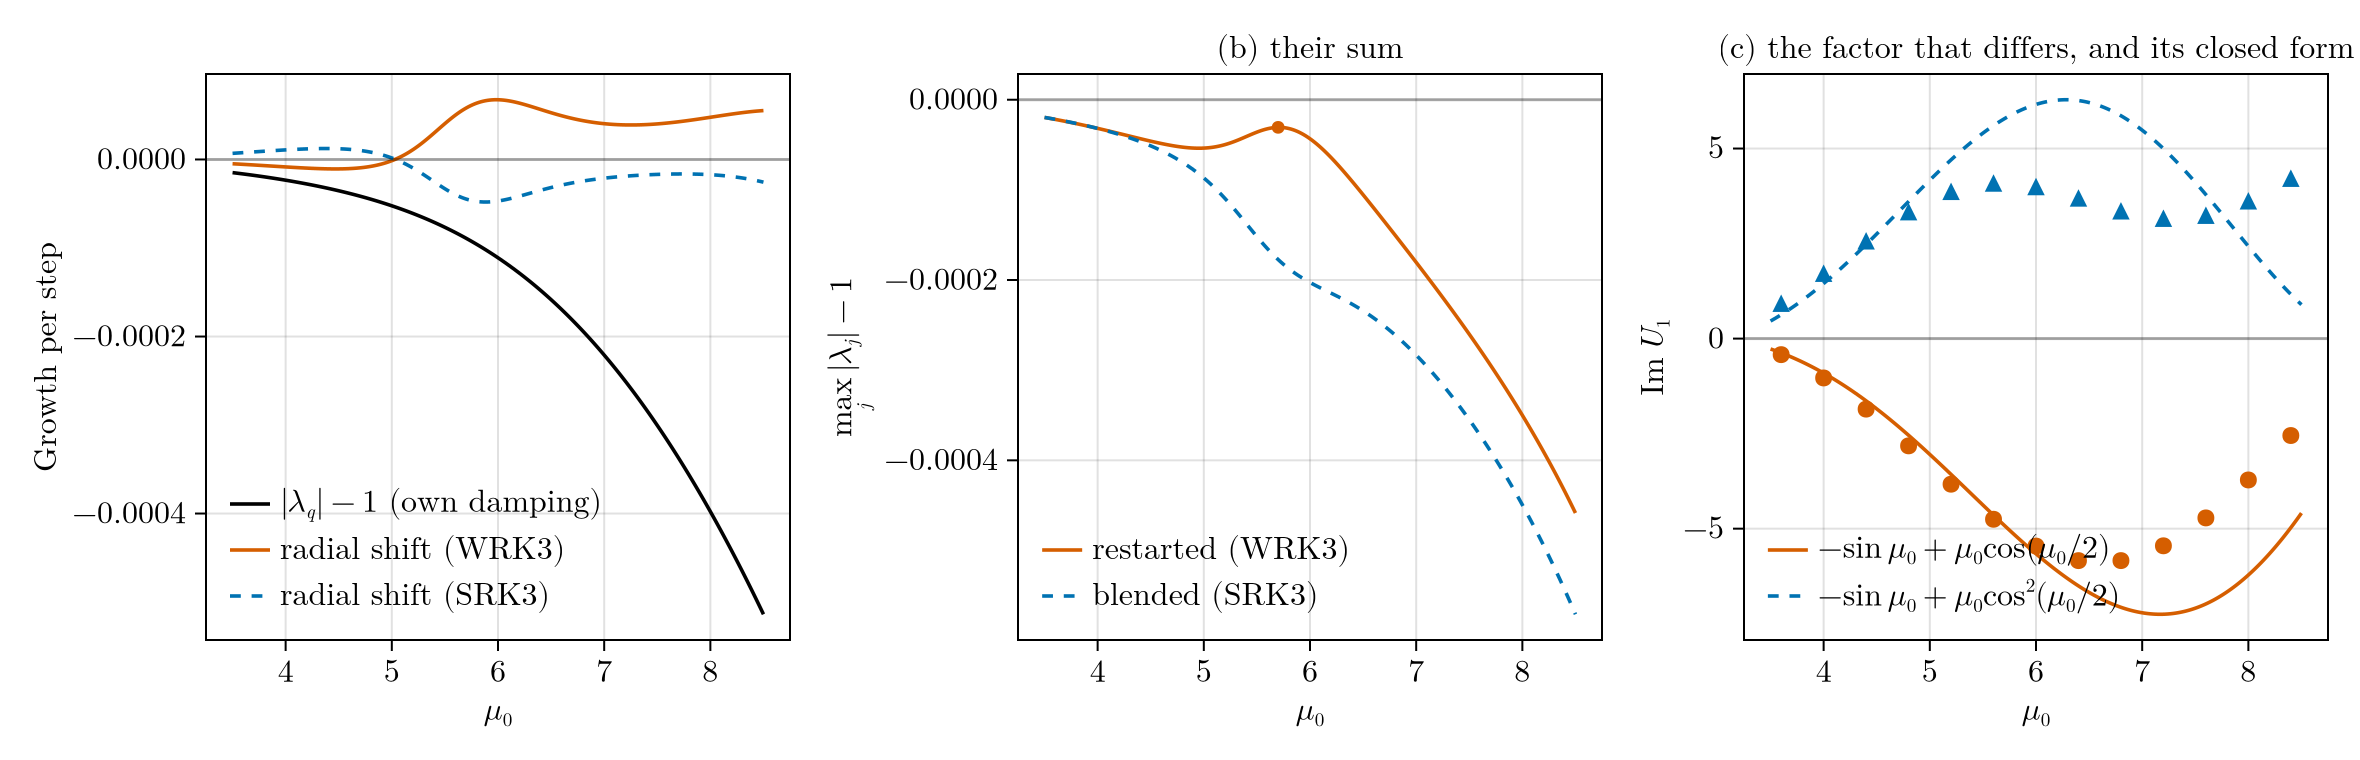

In [140]:
figure_injection(out = "injection.pdf")

### 2.1b  Is the perturbation basis well conditioned?


In [141]:
# ── Figure: is the eigenbasis of M_d well conditioned where we use it? ────────────────────────────
"""
    figure_conditioning(; NS = 64, ε = 0.06, Nm = 4, out = nothing)

The perturbation analysis of Section 4 expands about the eigenpairs of `M_d`, the mode-diagonal part of the
one-step operator, and needs them to be simple: the biorthogonal normalisation `ℓ r = 1` exists exactly when
`s = |ℓ̂ r̂| > 0` for unit-norm eigenvectors, and `s → 0` is a defective eigenvalue.  `1/s` is the eigenvalue
condition number.  Panel (a) sweeps `min_j s_j` over the Courant range for every composition; panel (b) drives the
forward--backward sub-step towards its known defect at `μ_B = 2`, where `s` must collapse, as a check that the
diagnostic sees what it is supposed to.
"""
function figure_conditioning(; NS = 64, ε = 0.06, Nm = 4, out = nothing)
    plot_setup()

    "s_j = |ℓ̂_j r̂_j| for every eigenvalue of the mode-diagonal part of M."
    function conditioning(M, Nm)
        s = Float64[]
        for q in 0:Nm
            F = eigen(M[2q+1:2q+2, 2q+1:2q+2]); R = F.vectors; L = inv(R)
            for j in 1:2; push!(s, 1/(norm(R[:,j])*norm(L[j,:]))); end
        end
        s
    end

    wts   = trig_weights(NS, 3/2, (-1.35, 0.5))
    cases = ((L"\text{WRK3-SE, FB}",  "#000000", (comp = WRK3,       ops = fb_ops )),
             (L"\text{WRK3-SE, RK3}", "#D55E00", (comp = WRK3,       ops = rk3_ops)),
             (L"\text{MRK4-SE, RK3}", "#0072B2", (comp = MRK4(0.23), ops = rk3_ops)),
             (L"\text{SRK3-SE, RK3}", "#009E73", (comp = SRK3,       ops = rk3_ops)))
    μs = range(0.2, 25.0, length = 2000)

    fig = Figure(size = (900, 380))
    ax1 = Axis(fig[1,1]; yscale = log10, xlabel = L"\mu_0", ylabel = L"\min_j |\hat{\ell}_j \hat{r}_j|",
               title = L"\text{(a) conditioning of the unperturbed eigenbasis}")
    for (name, col, kw) in cases
        s = [minimum(conditioning(step_matrix(se_step, μ/(kx*c0()), ε, Nm, wts; forcing = :frozen, kw...), Nm))
             for μ in μs]
        lines!(ax1, μs, s; color = col, label = name, linewidth = 2)
    end
    s_im = [minimum(conditioning(step_matrix(im_step, μ/(kx*c0()), ε, Nm, wts), Nm)) for μ in μs]
    lines!(ax1, μs, s_im; color = "#CC79A7", linestyle = :dash, linewidth = 2, label = L"\text{RK3-IM}")
    vspan!(ax1, 0.2, 20.0; color = (:gray, 0.12))   # the operating range
    axislegend(ax1; position = :lb, framevisible = false)

    # (b) the same diagnostic driven onto the forward--backward defect, mu_B = 2 mu0 / NS
    NSb  = 16
    wb   = trig_weights(NSb, 3/2, (-1.35, 0.5))
    μb   = range(4.0, 16.0, length = 120)
    sb   = [minimum(conditioning(step_matrix(se_step, μ/(kx*c0()), ε, Nm, wb;
                                             comp = WRK3, forcing = :frozen, ops = fb_ops), Nm)) for μ in μb]
    ax2 = Axis(fig[1,2]; yscale = log10, xlabel = L"\mu_B = 2\mu_0/N_S",
               ylabel = L"\min_j |\hat{\ell}_j \hat{r}_j|",
               title = L"\text{(b) approaching the forward-backward defect}")
    lines!(ax2, 2 .* μb ./ NSb, sb; color = "#000000", linewidth = 2)
    vlines!(ax2, [2.0]; color = :gray, linestyle = :dot)
    text!(ax2, 1.86, 4e-2; text = L"\mu_B = 2", align = (:right, :center), color = :gray)

    out === nothing || save(out, fig)
    fig
end


figure_conditioning

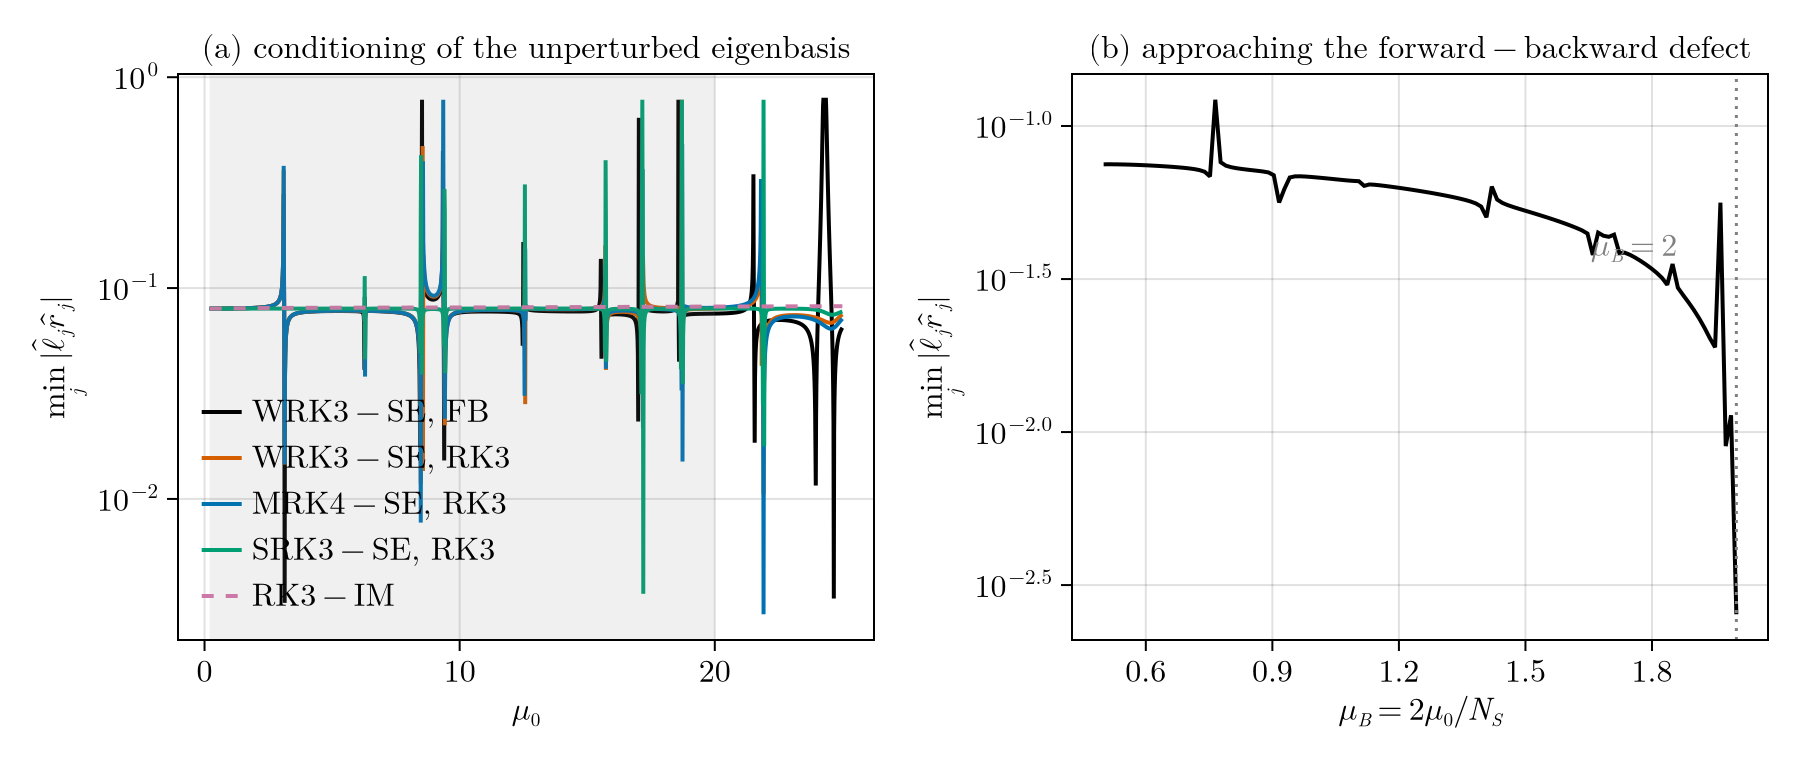

In [142]:
figure_conditioning(out = "conditioning.pdf")

### 2.1c  How the splitting error scales with the stratification


In [143]:
# ── How the blocks of V scale with the stratification ─────────────────────────────────────────────
"""
    figure_vscaling(; μ = 4.0, Nm = 4, NS = 64, out = nothing)

`V = M - M₀` is the splitting error: `M₀` advances every mode with the machinery it actually receives but with the
coupling switched off — the sub-cycled (or implicit) solve of its own system for the barotropic mode, the
composition's amplification polynomial for the baroclinic ones.  This sweeps `ε` and fits the power with which each
block of `V` grows, in the scaled variables where `u` and `h` entries are commensurate.  The exponents are the same
for every sub-step, composition and free surface, because they come from the modal weights and not from the time
discretization.
"""
function figure_vscaling(; μ = 4.0, Nm = 4, NS = 64, out = nothing)
    plot_setup()
    scaler(Nm) = Diagonal(vcat([[1/c0(), 1/H] for _ in 0:Nm]...))
    rescale(A, Nm) = (S = scaler(Nm); S*A/S)
    blk(A, q, p) = A[2q+1:2q+2, 2p+1:2p+2]

    "Amplification polynomial of the composition, applied to a matrix."
    function amplification(comp, z)
        n = size(z, 1); A = Matrix{ComplexF64}(I, n, n)
        if comp.blend === nothing
            for c in comp.γ; A = I(n) + Float64(c)*z*A; end
        else
            for (a, b) in comp.blend; A = Float64(a)*I(n) + Float64(b)*(I(n) + z)*A; end
        end
        A
    end

    "The mode's own system advanced by its own solver, no forcing: chi = psi = 1 by construction."
    function baro_ref(dt, α, wts, ops, comp, implicit)
        implicit || return stage_ops(dt, wts, α^2*g, ops)[1]
        B = Matrix{ComplexF64}(I, 2, 2)
        for c in comp.γ
            γ = Float64(c)*dt
            B = [1 γ*g*im*kx; γ*α^2*H*im*kx 1] \ Matrix{ComplexF64}(I, 2, 2)
        end
        B
    end

    function reference(dt, ε, Nm, wts, ops, comp; implicit = false)
        α, _ = modes(ε, Nm); L = modal_generator(ε, Nm) .* dt
        M0 = zeros(ComplexF64, 2(Nm+1), 2(Nm+1))
        M0[1:2, 1:2] = baro_ref(dt, α[1], wts, ops, comp, implicit)
        for q in 1:Nm; M0[2q+1:2q+2, 2q+1:2q+2] = amplification(comp, L[2q+1:2q+2, 2q+1:2q+2]); end
        M0
    end

    wts = trig_weights(NS, 3/2, (-1.35, 0.5))
    εs  = 10 .^ range(log10(0.005), log10(0.15), length = 12)
    cases = (("WRK3-SE, FB",  se_step, (comp=WRK3,       forcing=:frozen, ops=fb_ops ), WRK3,       false),
             ("WRK3-SE, RK3", se_step, (comp=WRK3,       forcing=:frozen, ops=rk3_ops), WRK3,       false),
             ("MRK4-SE, RK3", se_step, (comp=MRK4(0.23), forcing=:frozen, ops=rk3_ops), MRK4(0.23), false),
             ("SRK3-SE, RK3", se_step, (comp=SRK3,       forcing=:frozen, ops=rk3_ops), SRK3,       false),
             ("RK3-IM",       im_step, NamedTuple(),                                    WRK3,       true))
    labels = (L"\|V_{00}\|", L"\|V_{qq}\|", L"\|V_{0q}\|", L"\|V_{q0}\|")
    cols   = ("#D55E00", "#0072B2", "#009E73", "#CC79A7")

    fig = Figure(size = (640, 470))
    ax = Axis(fig[1,1]; xscale = log10, yscale = log10, xlabel = L"\varepsilon",
              ylabel = L"\|V\ \text{block}\|", title = L"\text{how the splitting error scales with stratification}")
    @printf("%-15s %-8s %-8s %-8s %s\n", "scheme", "V_00", "V_qq", "V_0q", "V_q0")
    for (name, stepper, kw, comp, imp) in cases
        n = zeros(length(εs), 4)
        for (i, ε) in enumerate(εs)
            dt = μ/(kx*c0())
            M  = rescale(step_matrix(stepper, dt, ε, Nm, wts; kw...), Nm)
            M0 = rescale(reference(dt, ε, Nm, wts, get(kw, :ops, rk3_ops), comp; implicit = imp), Nm)
            V  = M - M0
            n[i,:] = [norm(blk(V,0,0)), norm(blk(V,1,1)), norm(blk(V,0,1)), norm(blk(V,1,0))]
        end
        for k in 1:4; lines!(ax, εs, n[:,k]; color = cols[k], linewidth = 1.4); end
        @printf("%-15s %-8.2f %-8.2f %-8.2f %.2f\n", name,
                [log(n[end,k]/n[1,k])/log(εs[end]/εs[1]) for k in 1:4]...)
    end
    for (k, lab) in enumerate(labels)
        lines!(ax, [NaN], [NaN]; color = cols[k], linewidth = 2, label = lab)
    end
    lines!(ax, εs, 6 .* εs;    color = :gray, linestyle = :dot,     label = L"\varepsilon")
    lines!(ax, εs, 6 .* εs.^2; color = :gray, linestyle = :dashdot, label = L"\varepsilon^2")
    axislegend(ax; position = :lt, framevisible = false, nbanks = 2)
    out === nothing || save(out, fig)
    fig
end


figure_vscaling

scheme          V_00     V_qq     V_0q     V_q0
WRK3-SE, FB     1.00     1.99     0.98     1.00
WRK3-SE, RK3    1.00     1.98     0.98     1.00
MRK4-SE, RK3    1.00     1.96     0.98     0.98
SRK3-SE, RK3    1.00     1.98     0.99     0.97
RK3-IM          1.01     1.98     0.99     0.98


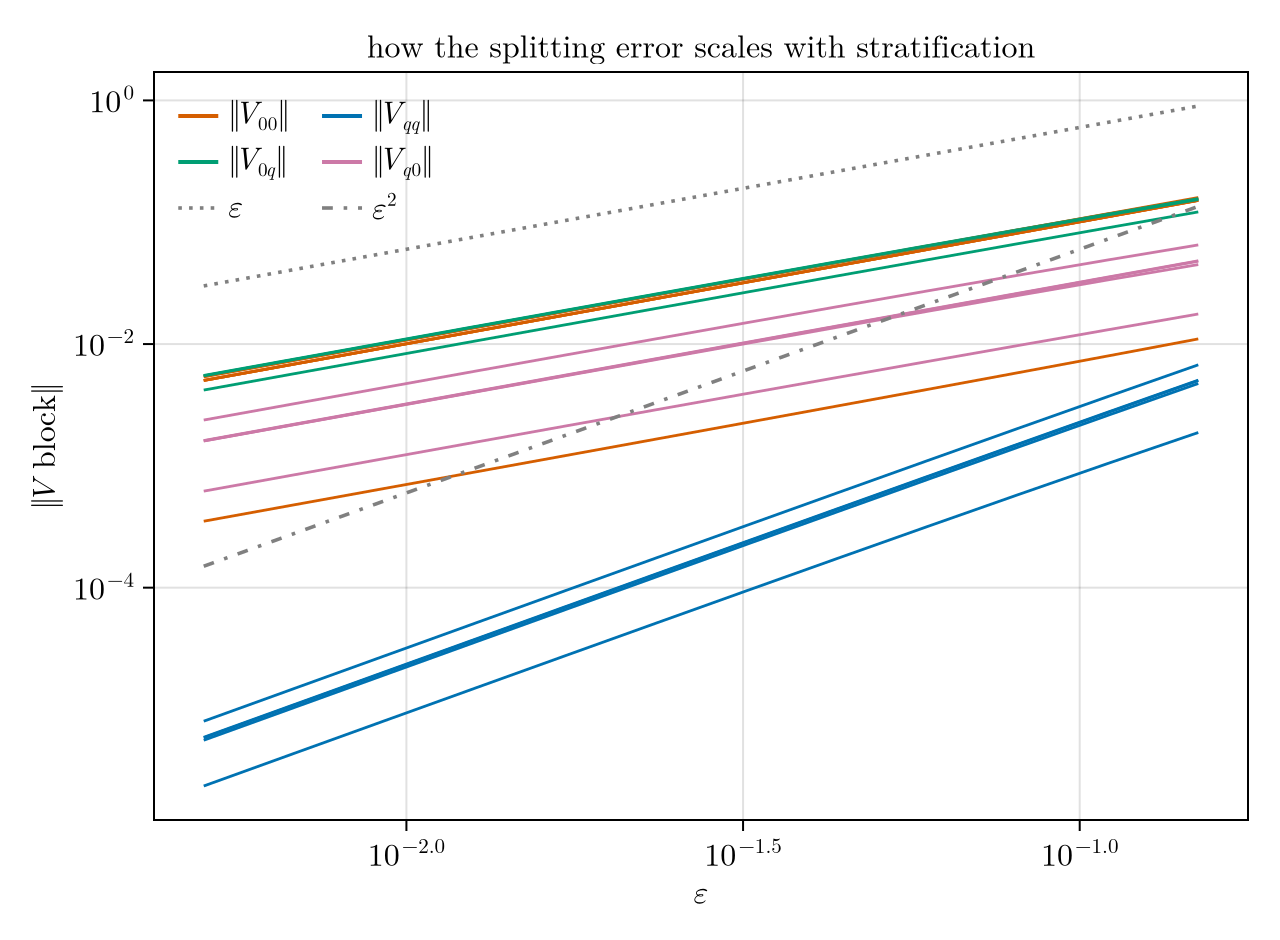

In [144]:
figure_vscaling(out = "v-scaling.pdf")

### 2.1d  The terms of the eigenvalue shift

The section rests on splitting the growth into the composition's own damping, a direct term, and a
second-order term the coupling produces. Everything below builds those three and checks them against
diagonalisation of the one-step matrix.

In [145]:
using Statistics
# ── The four terms of the eigenvalue shift, and their verification ────────────────────────────────
# `M₀` is the scheme with the coupling switched off: each mode advanced by the machinery it actually
# receives — the sub-cycled (or implicit) solve for the barotropic mode, the composition's amplification
# polynomial for the baroclinic ones.  `V = M - M₀` is the splitting error.  The shift of an eigenvalue
# of `M₀` under `V` is `δλ = V_jj + Σ_l V_jl V_lj/(λ_j - λ_l)`, and every quantity below is one piece of it.
# `qsel` selects which baroclinic mode plays the role of `j`; by default the least damped one.
sc(Nm)      = Diagonal(vcat([[1/c0(), 1/H] for _ in 0:Nm]...))
rescale(A)  = (S = sc((size(A,1) ÷ 2) - 1); S*A/S)

"The barotropic window over a stage of Courant number μ, in the scaled variables."
baro_window(μ, wts, ops, implicit) = implicit ? inv(ComplexF64[1 im*μ; im*μ 1]) :
    (S = Diagonal([1/c0(), 1/H]); S*stage_ops(μ/(kx*c0()), wts, g, ops)[1]/S)

"The composition's amplification polynomial applied to a matrix."
function amplif(comp, z)
    n = size(z, 1); A = Matrix{ComplexF64}(I, n, n)
    if comp.blend === nothing
        for c in comp.γ; A = I(n) + Float64(c)*z*A; end
    else
        for (a, b) in comp.blend; A = Float64(a)*I(n) + Float64(b)*(I(n) + z)*A; end
    end
    A
end

"""
The scheme restricted to a single mode of speed ratio `α`: the same stage matrices with the modal
vectors replaced by scalars, `χ = ψ = 1` and `Π = α² - 1`.  This is `𝒮`, the barotropic mode's own solver.
"""
function mode_solver(μ₀, α, wts, ops, comp, implicit)
    J2 = ComplexF64[0 1; 1 0]; Jq = ComplexF64[0 1; α^2 0]
    X  = Diagonal(ComplexF64[1, α^2]); Yψ = Matrix{ComplexF64}(I,2,2); YΠ = ComplexF64[0 0; 0 α^2-1]
    Ms = length(comp.γ)
    β  = comp.blend === nothing ? nothing : ntuple(m -> prod(Float64(comp.blend[j][2]) for j in m:Ms), Ms)
    hist = [Matrix{ComplexF64}(I,2,2)]; S = Matrix{ComplexF64}(I,2,2)
    for m in 1:Ms
        cm = Float64(comp.γ[m]); θ = μ₀*α
        μm = comp.blend === nothing ? cm*θ : θ
        μs = comp.blend === nothing ? cm*μ₀ : μ₀
        W  = baro_window(μm, wts, ops, implicit)
        am, bm = comp.blend === nothing ? (0.0, 1.0) : Float64.(comp.blend[m])
        ω  = comp.blend === nothing ? 1.0 : bm
        A0 = comp.blend === nothing ? Matrix{ComplexF64}(I,2,2) : am*Matrix{ComplexF64}(I,2,2)
        B0 = comp.blend === nothing ? -im*μs*Jq : bm*(I - im*μ₀*Jq)
        𝔞 = ω*X*(W - I)*Yψ
        𝔟 = ω*X*((W - I)*YΠ + im*μm*J2)
        if comp.blend !== nothing && m == Ms
            Gβ = sum(β[j]*hist[j] for j in 1:Ms)
            𝔞 = ω*X*(W - I)*(Yψ + YΠ*Gβ); 𝔟 = ω*X*(im*μm*J2)
        end
        S = (A0 + 𝔞) + (B0 + 𝔟)*hist[end]; push!(hist, S)
    end
    S
end

"`M₀` of the section: block diagonal, the solver on the barotropic mode and the polynomial on the others."
function uncoupled_matrix(μ₀, ε, Nm, wts, ops, comp; implicit = false)
    α, _ = modes(ε, Nm); M0 = zeros(ComplexF64, 2(Nm+1), 2(Nm+1))
    S = mode_solver(μ₀, α[1], wts, ops, comp, implicit)
    M0[1:2, 1:2] = S
    for q in 1:Nm
        M0[2q+1:2q+2, 2q+1:2q+2] = amplif(comp, -im*μ₀*ComplexF64[0 1; α[q+1]^2 0])
    end
    M0
end

"Eigenpairs of the block-diagonal `M₀`, one 2x2 block at a time, biorthogonally normalised."
function uncoupled_eigenpairs(M0, Nm)
    n = 2(Nm+1); λ = ComplexF64[]; mode = Int[]
    R = zeros(ComplexF64, n, n); L = zeros(ComplexF64, n, n); k = 0
    for q in 0:Nm
        idx = [2q+1, 2q+2]; F = eigen(M0[idx, idx]); Rq = F.vectors; Lq = inv(Rq)
        for s in 1:2
            k += 1; push!(λ, F.values[s]); push!(mode, q)
            R[idx, k] = Rq[:, s]; L[k, idx] = Lq[s, :]
        end
    end
    λ, R, L, mode
end

"""
    shift_terms(μ₀, ε, Nm, wts; ...)

Every piece of the eigenvalue shift of the least damped baroclinic mode: the mode's own damping, the
direct term `n₀ = V_jj/λ_j`, the coupling numerators `n_l = V_jl V_lj / λ_j²`, their radial parts, and
the growth obtained by diagonalising `M` directly.
"""
function shift_terms(μ₀, ε, Nm, wts; comp = WRK3, ops = rk3_ops, implicit = false, forcing = :frozen, qsel = nothing)
    dt = μ₀/(kx*c0())
    stepper = implicit ? im_step : se_step
    kw = implicit ? NamedTuple() : (comp = comp, forcing = forcing, ops = ops)
    M  = rescale(step_matrix(stepper, dt, ε, Nm, wts; kw...))
    M0 = uncoupled_matrix(μ₀, ε, Nm, wts, ops, comp; implicit = implicit)
    V  = M - M0
    λ, R, L, mode = uncoupled_eigenpairs(M0, Nm); Ṽ = L*V*R
    cand = qsel === nothing ? [k for k in eachindex(λ) if mode[k] ≥ 1] : [k for k in eachindex(λ) if mode[k] == qsel]
    j = cand[argmax(abs.(λ[cand]))]                      # the requested mode, or the least damped baroclinic one
    rad(δ) = real(conj(λ[j])*δ)/abs(λ[j])
    n₀ = Ṽ[j,j]/λ[j]
    nl = Dict(l => Ṽ[j,l]*Ṽ[l,j]/λ[j]^2 for l in eachindex(λ) if l != j)
    second = sum(Ṽ[j,l]*Ṽ[l,j]/(λ[j] - λ[l]) for l in eachindex(λ) if l != j)
    baro = sum(Ṽ[j,l]*Ṽ[l,j]/(λ[j] - λ[l]) for l in eachindex(λ) if mode[l] == 0)
    ev = eigvals(M); λtrue = ev[argmin(abs.(ev .- λ[j]))]
    λb = λ[argmax([mode[l] == 0 ? abs(λ[l]) : -1.0 for l in eachindex(λ)])]
    αv, ψv = modes(ε, Nm); χj = ψv[mode[j]+1]*αv[mode[j]+1]^2
    (damping = abs(λ[j]) - 1, n₀ = n₀, radial₀ = rad(Ṽ[j,j]), radial₂ = rad(second), χq = χj, q = mode[j],
     radial_baro = rad(baro), nl = nl, λ = λ, mode = mode, j = j, λb = λb,
     growth = abs(λtrue) - 1, Kmeas = sum(nl[l] for l in eachindex(λ) if mode[l] == 0))
end

function phase_matched(t; baro_only = true)
  a = abs(t.λ[t.j])
  s = 0.0
  for l in eachindex(t.λ)
      l == t.j && continue
      baro_only && t.mode[l] != 0 && continue
      ρ = abs(t.λ[l])
      abs(a - ρ) < 1e-12 && continue                 # the estimate diverges at coincidence
      s += a^2 * real(t.nl[l]) / (a - ρ)
  end
  s
end

function real_only(t; baro_only = true)
    a = abs(t.λ[t.j]); s = 0.0
    for l in eachindex(t.λ)
        l == t.j && continue
        baro_only && t.mode[l] != 0 && continue
        r = abs(t.λ[l])/a
        ψ = angle(t.λ[l]) - angle(t.λ[t.j])
        D = 1 - 2r*cos(ψ) + r^2
        s += a*(1 - r*cos(ψ))*real(t.nl[l])/D
    end
    s
end

real_only (generic function with 1 method)

In [146]:
# ── Control: the terms are what the section says they are ────────────────────────────────────────
# `M₀` must be block diagonal, its eigenvectors biorthogonal, and the expansion must reproduce the
# growth obtained by diagonalising `M`.  The cell fails loudly if any of it breaks.
let ε = 0.1, Nm = 6, wts = optasym_weights(48)
    for (nm, comp, ops, imp) in (("WRK3-SE", WRK3, rk3_ops, false), ("MRK4-SE", MRK4(0.23), rk3_ops, false),
                                 ("SRK3-SE", SRK3, rk3_ops, false), ("RK3-IM", WRK3, rk3_ops, true))
        M0 = uncoupled_matrix(6.0, ε, Nm, wts, ops, comp; implicit = imp)
        offblock = maximum(abs(M0[2q+i, 2p+j]) for q in 0:Nm, p in 0:Nm, i in 1:2, j in 1:2 if q != p)
        @assert offblock == 0 "M₀ is not block diagonal for $nm"
        λ, R, L, mode = uncoupled_eigenpairs(M0, Nm)
        @assert norm(L*R - I) < 1e-9 "the eigenvectors are not biorthogonal for $nm"
        errs = [(t = shift_terms(μ, ε, Nm, wts; comp = comp, ops = ops, implicit = imp);
                 abs((t.damping + t.radial₀ + t.radial₂) - t.growth)/abs(t.damping)) for μ in 1.0:0.5:16.0]
        share = [(t = shift_terms(μ, ε, Nm, wts; comp = comp, ops = ops, implicit = imp);
                  abs(t.radial_baro)/abs(t.radial₂)) for μ in 2.0:2.0:12.0]
        @printf("%-9s  expansion residual: median %6.3f%%  worst %6.2f%%   barotropic share of the sum: min %5.1f%%\n",
                nm, 100*median(errs), 100*maximum(errs), 100*minimum(share))
    end
end

WRK3-SE    expansion residual: median  0.414%  worst  14.02%   barotropic share of the sum: min  98.3%
MRK4-SE    expansion residual: median  4.950%  worst 173.65%   barotropic share of the sum: min 100.0%
SRK3-SE    expansion residual: median  0.429%  worst   3.16%   barotropic share of the sum: min  99.1%
RK3-IM     expansion residual: median  0.002%  worst   9.46%   barotropic share of the sum: min  73.0%


#### The three terms of the growth, checked against diagonalisation

Nothing that follows is licensed until the decomposition reproduces the growth the one-step matrix
actually has, so this comes first.

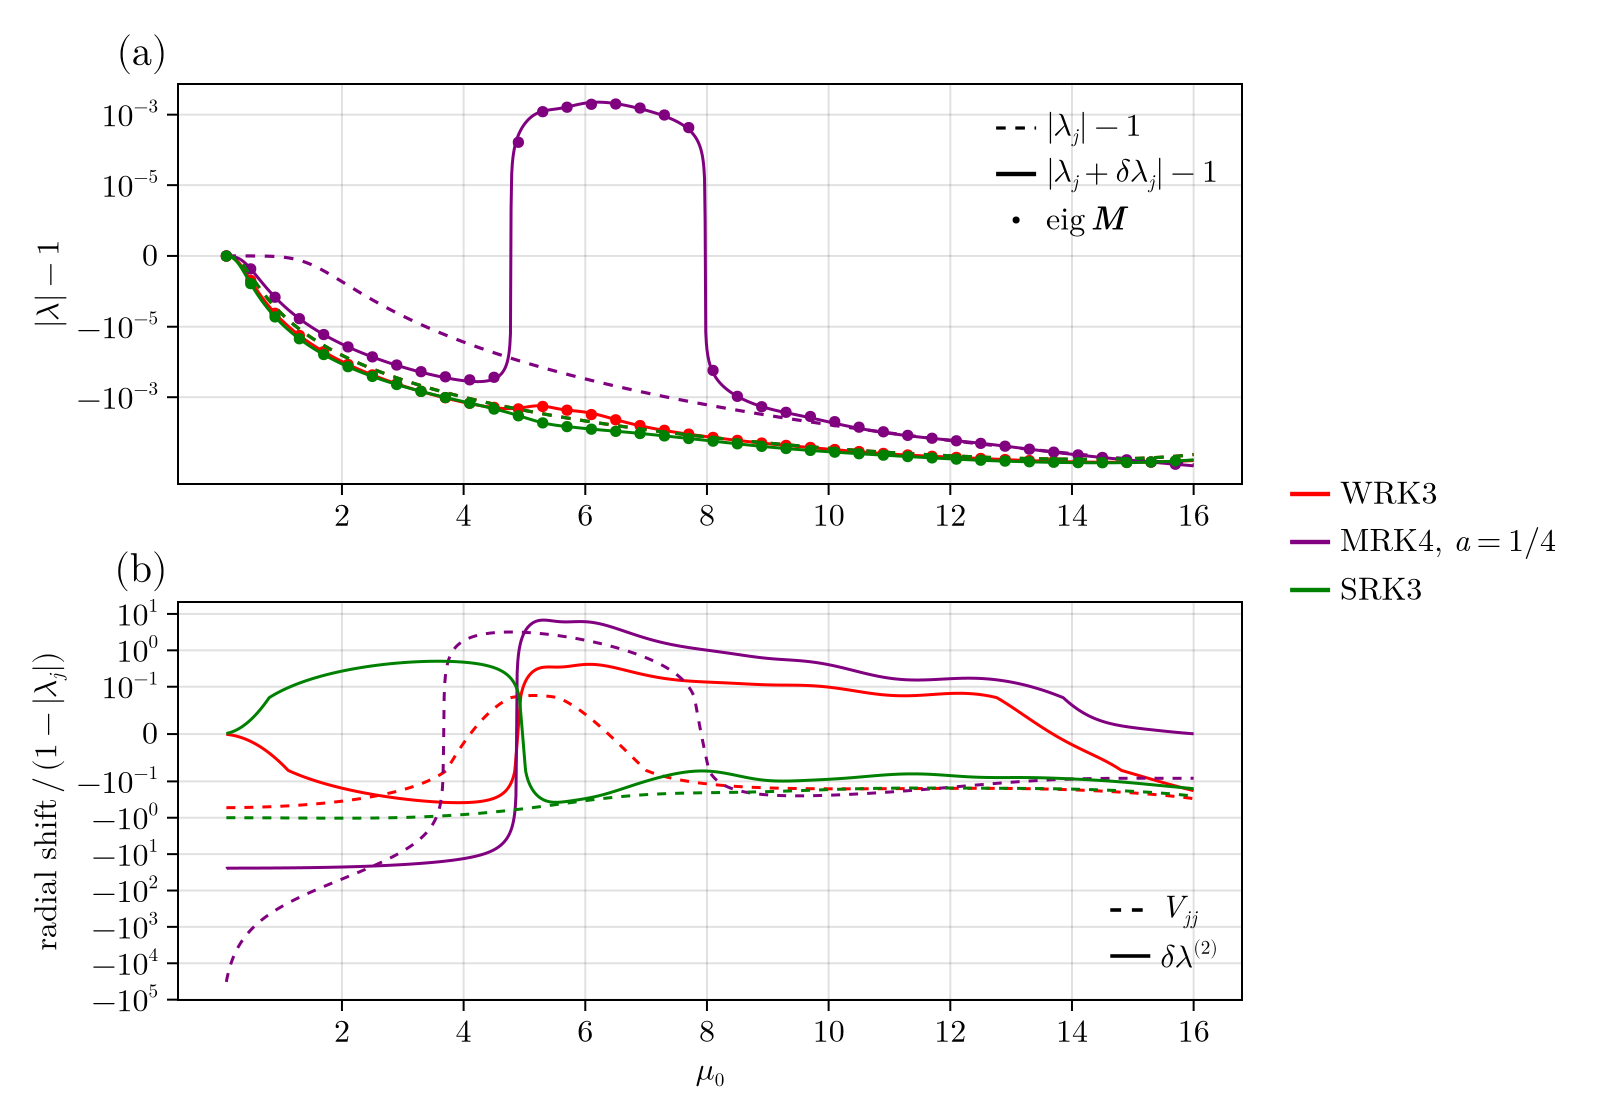

In [160]:
# ── Figure: the three terms of the growth, and the expansion checked against diagonalisation ──────
"""
    figure_terms(; ε, Nm, wts, out)

The growth of the least damped baroclinic mode, separated into the three terms of the section: the
composition's own damping, the direct term `Re n₀`, and the second-order term the coupling produces.
Panel (a) plots them against `μ₀` together with their sum and with the growth obtained by diagonalising
`M`; panel (b) is the residual of the two-term expansion, as a fraction of the mode's own damping.
"""
function figure_terms(; ε = 0.1, Nm = 8, wts = optasym_weights(48), out = nothing)
    plot_setup()
    slog(x; e = 1e-7) = sign(x)*log10(1 + abs(x)/e)

    ticks(t) = (t, [L"%$(string(ti))" for ti in t])
    eticks(t) = (10.0 .^ t, [L"10^{%$(string(ti))}" for ti in t])
    seticks(t) = ([-10.0 .^ t..., 0, 10.0 .^ t...], [[L"-10^{%$(string(ti))}" for ti in t]..., L"0", [L"10^{%$(string(ti))}" for ti in t]...])
    function symticks(pw; e = 1e-7)
        v = vcat([-10.0^p for p in reverse(pw)], 0.0, [10.0^p for p in pw])
        (sign.(v) .* log10.(1 .+ abs.(v) ./ e),
         vcat([L"-10^{%$p}" for p in reverse(pw)], L"0", [L"10^{%$p}" for p in pw]))
    end
    
    μs = collect(0.1:0.01:16.0)
    T1  = [shift_terms(μ, ε, Nm, wts; comp = WRK3,      ops = rk3_ops, qsel = 1) for μ in μs]
    T2  = [shift_terms(μ, ε, Nm, wts; comp = MRK4(1/4), ops = rk3_ops, qsel = 1) for μ in μs]
    T3  = [shift_terms(μ, ε, Nm, wts; comp = SRK3,      ops = rk3_ops, qsel = 1) for μ in μs]
    fig = Figure(size = (800, 560))
    ga  = GridLayout(fig[1, 1])

    ax = Axis(ga[1,1]; xlabel = "", xticks = ticks([2, 4, 6, 8, 10, 12, 14, 16, 18]), yticks = symticks(-5:2:-2), ylabel = L"|\lambda| - 1")
    schemes = ((L"\text{WRK3}",         T1, :red),
               (L"\text{MRK4},\ a=1/4", T2, :purple),
               (L"\text{SRK3}",         T3, :green))

    for (_, T, col) in schemes
        lines!(ax, μs, slog.(getfield.(T, :damping)); color = col, linewidth = 1.6, linestyle = :dash)
        lines!(ax, μs, slog.(getfield.(T, :damping) .+ getfield.(T, :radial₀) .+ getfield.(T, :radial₂)); color = col, linewidth = 1.5)
        scatter!(ax, μs[1:40:end], slog.(getfield.(T, :growth))[1:40:end]; color = col, markersize = 8)
    end

    lines!(ax, [NaN], [NaN]; color = :black, linewidth = 1.6, linestyle = :dash, label = L"|\lambda_j| - 1")
    lines!(ax, [NaN], [NaN]; color = :black, linewidth = 2.2, label = L"|\lambda_j + \delta\lambda_j| - 1")
    scatter!(ax, [NaN], [NaN]; color = :black, markersize = 5, label = L"\mathrm{eig}\,\mathbf{M}")
    axislegend(ax; position = :rt, framevisible = false)
    
    axb = Axis(ga[2,1]; yscale = Makie.Symlog10(5e-2), yticks = seticks([-1, 0, 1, 2, 3, 4, 5, 6, 7]), xlabel = L"\mu_0", xticks = ticks([2, 4, 6, 8, 10, 12, 14, 16, 18]), ylabel = L"\text{radial shift} \,/\, (1 - |\lambda_j|)")
    for (_, T, col) in schemes
        lines!(axb, μs, getfield.(T, :radial₀)./abs.(getfield.(T, :damping)); color = col, linewidth = 1.5, linestyle = :dash)
        lines!(axb, μs, getfield.(T, :radial₂)./abs.(getfield.(T, :damping)); color = col, linewidth = 1.5)
    end
    lines!(axb, [NaN], [NaN]; color = :black, linewidth = 1.8, linestyle = :dash, label = L"V_{jj}")
    lines!(axb, [NaN], [NaN]; color = :black, linewidth = 1.8, label = L"\delta\lambda^{(2)}")
    axislegend(axb; position = :rb, framevisible = false)
    
    Legend(ga[1:2, end+1],
           [LineElement(color = c, linewidth = 2.2) for (_, _, c) in schemes],
           [l for (l, _, _) in schemes];
           framevisible = false, labelsize = 16, rowgap = 4)
    
    Label(ga[1, 1, TopLeft()], L"\text{(a)}", fontsize = 20, padding = (0, 5, 5, 0), halign = :right)
    Label(ga[2, 1, TopLeft()], L"\text{(b)}", fontsize = 20, padding = (0, 5, 5, 0), halign = :right)
    
    rowgap!(ga, 10)
    out === nothing || save(out, fig)
    fig
end

figure_terms(out = "/Users/simonesilvestri/MIT Dropbox/Simone Silvestri/Apps/Overleaf/timestepper/terms.pdf")

#### The two numerators: their order in the stratification, and which partner carries the sum

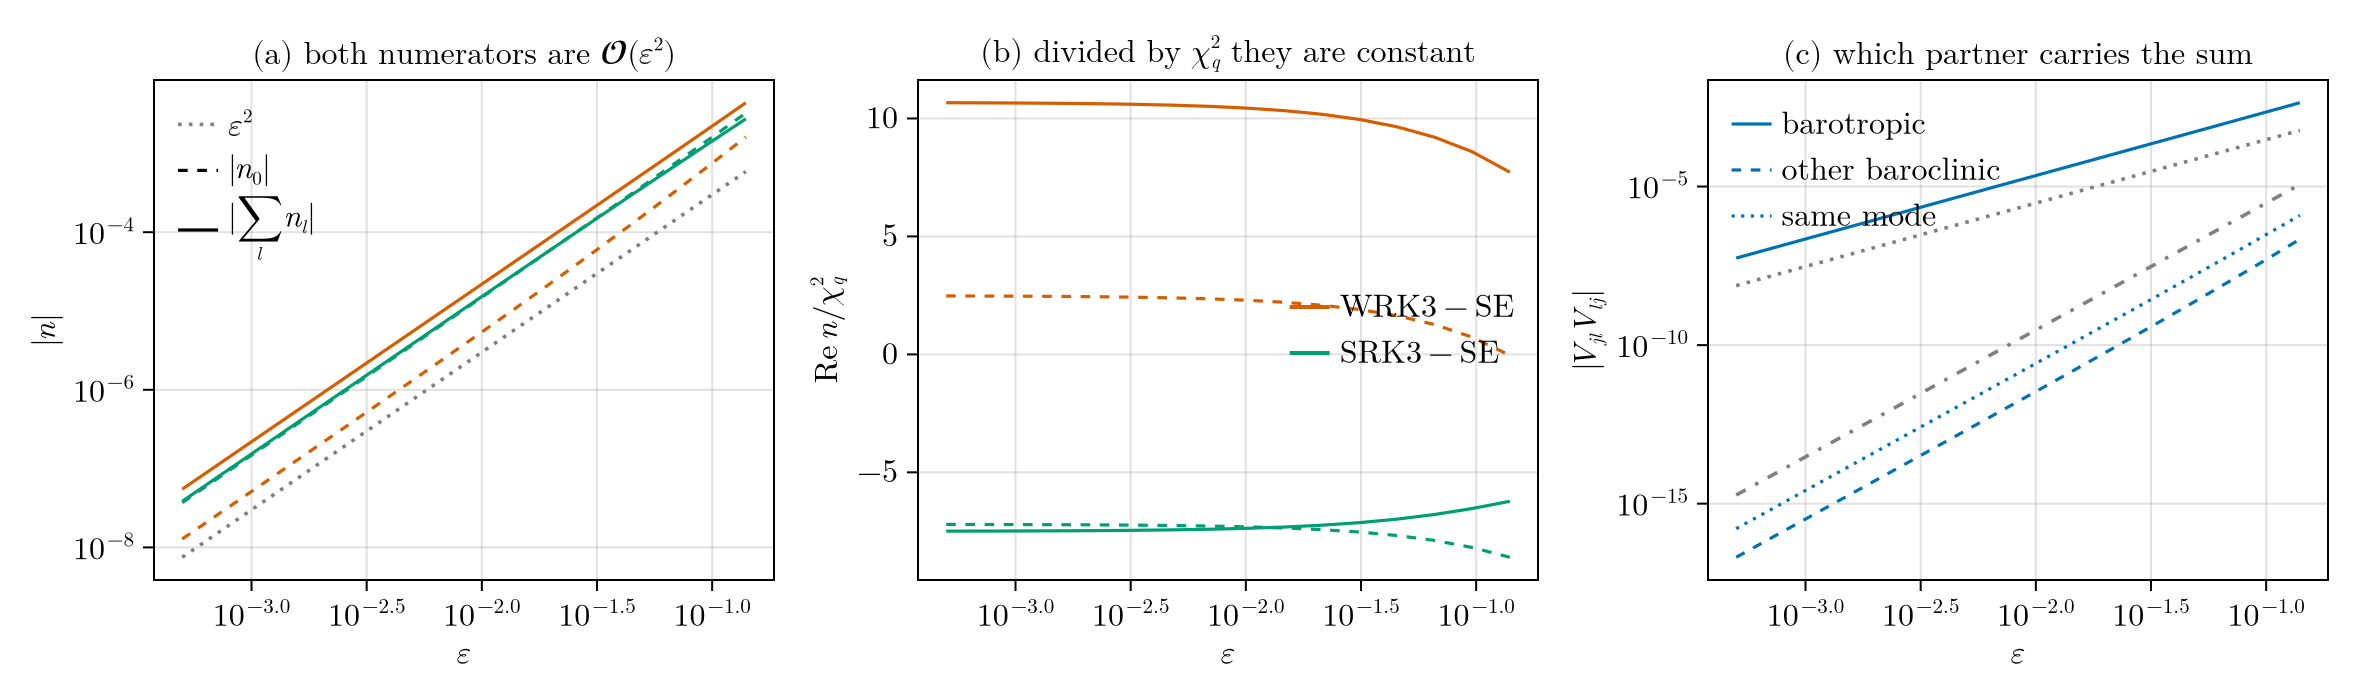

In [161]:
# ── Figure: the two numerators, their order in ε, and which partner carries the sum ───────────────
"""
    figure_numerators(; μ₀, Nm, wts, out)

Both numerators are `χ_q²` times a quantity free of the stratification.  Panel (a) sweeps `ε` and shows
`|n₀|` and `|Σ_l n_l|` following `ε²`; panel (b) divides them by `χ_q²` and shows the quotients settling on
the constants `K₀` and `K` of the appendix; panel (c) splits the second-order sum by the mode of the partner.
"""
function figure_numerators(; μ₀ = 6.0, Nm = 2, wts = optasym_weights(48), out = nothing)
    plot_setup()
    εs = 10 .^ range(log10(5e-4), log10(0.14), 16)
    cases = (("WRK3-SE", WRK3, rk3_ops, "#D55E00"), ("SRK3-SE", SRK3, rk3_ops, "#009E73"))
    fig = Figure(size = (1180, 350))
    axa = Axis(fig[1,1]; xscale = log10, yscale = log10, xlabel = L"\varepsilon",
               ylabel = L"|n|", title = L"\text{(a) both numerators are }\mathcal{O}(\varepsilon^2)")
    axb = Axis(fig[1,2]; xscale = log10, xlabel = L"\varepsilon", ylabel = L"\mathrm{Re}\,n/\chi_q^2",
               title = L"\text{(b) divided by }\chi_q^2\text{ they are constant}")
    axc = Axis(fig[1,3]; xscale = log10, yscale = log10, xlabel = L"\varepsilon",
               ylabel = L"|V_{jl}V_{lj}|", title = L"\text{(c) which partner carries the sum}")
    for (nm, comp, ops, col) in cases
        T = [shift_terms(μ₀, ε, Nm, wts; comp = comp, ops = ops, qsel = 1) for ε in εs]
        χq = getfield.(T, :χq)
        lines!(axa, εs, abs.(getfield.(T, :n₀));   color = col, linewidth = 1.6, linestyle = :dash)
        lines!(axa, εs, abs.(getfield.(T, :Kmeas)); color = col, linewidth = 1.6)
        lines!(axb, εs, real.(getfield.(T, :n₀))./χq.^2;   color = col, linewidth = 1.6, linestyle = :dash)
        lines!(axb, εs, real.(getfield.(T, :Kmeas))./χq.^2; color = col, linewidth = 1.6)
    end
    lines!(axa, εs, 3e-2 .* εs.^2; color = :gray, linestyle = :dot, label = L"\varepsilon^2")
    lines!(axa, [NaN], [NaN]; color = :black, linewidth = 1.6, linestyle = :dash, label = L"|n_0|")
    lines!(axa, [NaN], [NaN]; color = :black, linewidth = 1.6, label = L"|\sum_l n_l|")
    axislegend(axa; position = :lt, framevisible = false)
    lines!(axb, [NaN], [NaN]; color = "#D55E00", linewidth = 2, label = L"\text{WRK3-SE}")
    lines!(axb, [NaN], [NaN]; color = "#009E73", linewidth = 2, label = L"\text{SRK3-SE}")
    axislegend(axb; position = :rc, framevisible = false)
    # panel (c): the sum by partner type
    for (lab, sel, ls) in ((L"\text{barotropic}", :baro, :solid),
                           (L"\text{other baroclinic}", :other, :dash),
                           (L"\text{same mode}", :same, :dot))
        y = map(εs) do ε
            t = shift_terms(μ₀, ε, Nm, wts; comp = WRK3, ops = rk3_ops, qsel = 1)
            j, mode, λ = t.j, t.mode, t.λ
            s = 0.0
            for l in eachindex(λ)
                l == j && continue
                ok = sel === :baro ? mode[l] == 0 :
                     sel === :same ? mode[l] == mode[j] : (mode[l] != 0 && mode[l] != mode[j])
                ok && (s += abs(t.nl[l])*abs(λ[j])^2)
            end
            s + 1e-30
        end
        lines!(axc, εs, y; color = "#0072B2", linestyle = ls, linewidth = 1.6, label = lab)
    end
    lines!(axc, εs, 3e-2 .* εs.^2; color = :gray, linestyle = :dot)
    lines!(axc, εs, 3e-2 .* εs.^4; color = :gray, linestyle = :dashdot)
    axislegend(axc; position = :lt, framevisible = false)
    out === nothing || save(out, fig)
    fig
end

figure_numerators(out = "numerators.pdf")

#### The four quantities, one panel each

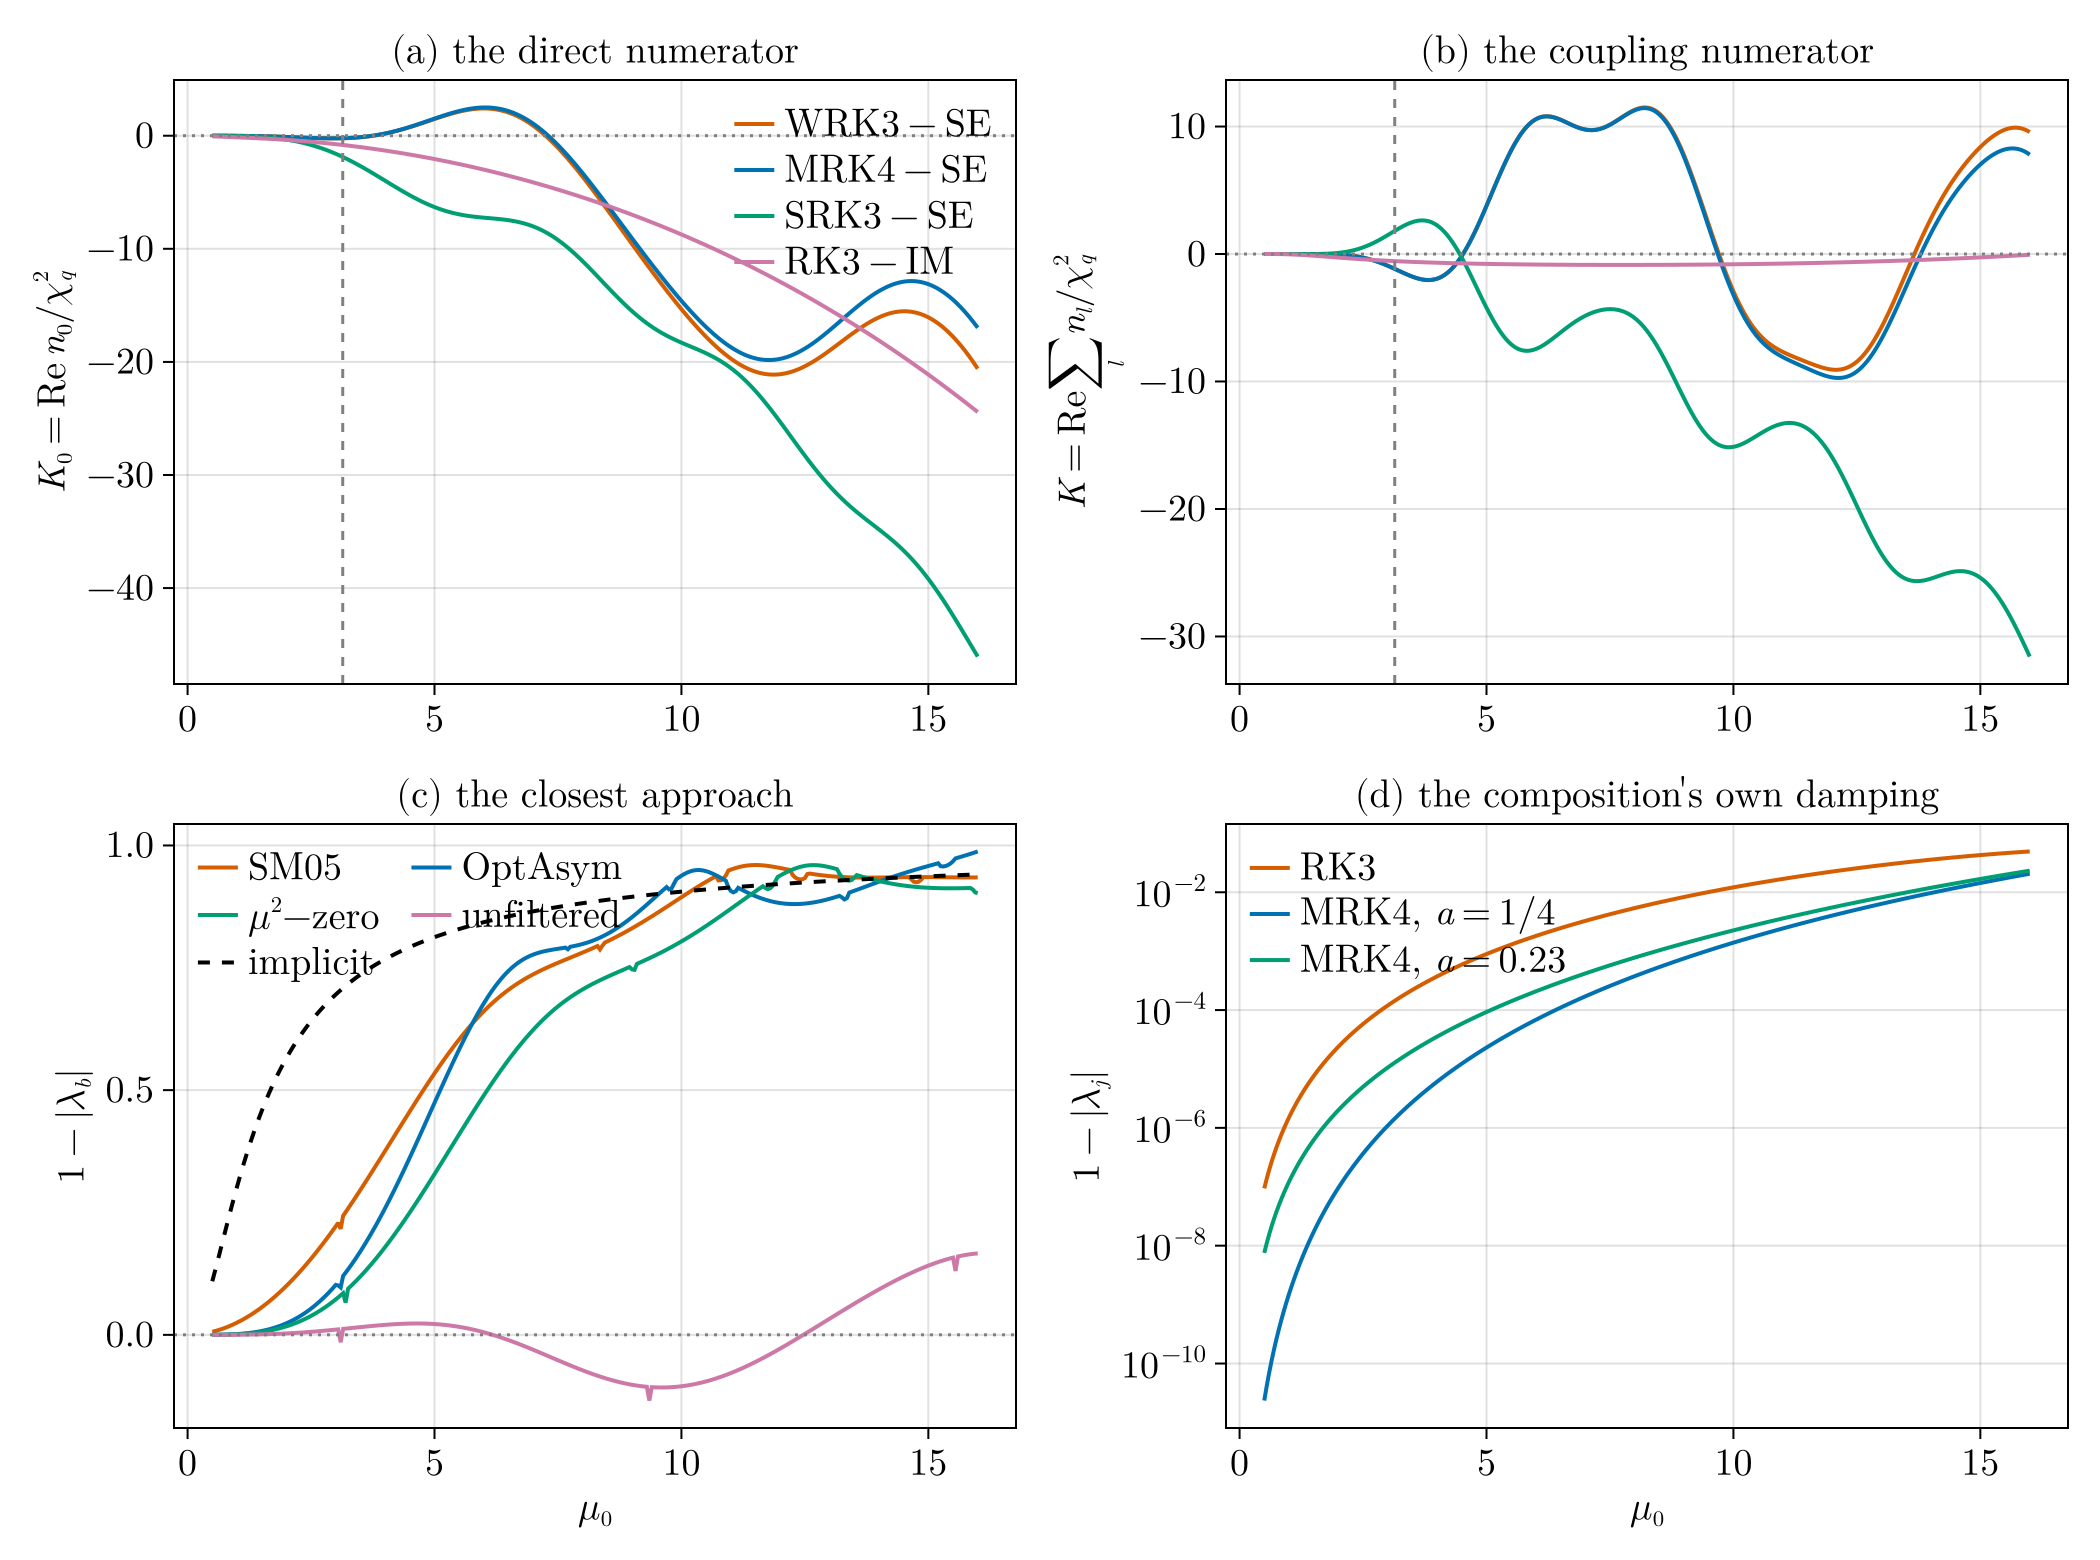

In [116]:
# ── Figure: the four terms, one panel each ───────────────────────────────────────────────────────
"""
    figure_signs(; ε, Nm, q, out)

The four quantities the growth is built from, each swept against the Courant number for the first
baroclinic mode: the two numerators, the closest the barotropic family comes to it, and the damping the
composition itself provides.  Each is controlled by a different part of the scheme, which is why each
panel varies a different ingredient.
"""
function figure_signs(; ε = 0.004, Nm = 3, q = 1, εk = 0.06, out = nothing)
    plot_setup(); set_theme!(theme_latexfonts(); fontsize = 19)
    μs = collect(0.5:0.05:16.0)
    comps = ((L"\text{WRK3-SE}", WRK3, rk3_ops, false, "#D55E00"),
             (L"\text{MRK4-SE}", MRK4(0.23), rk3_ops, false, "#0072B2"),
             (L"\text{SRK3-SE}", SRK3, rk3_ops, false, "#009E73"),
             (L"\text{RK3-IM}",  WRK3, rk3_ops, true,  "#CC79A7"))
    fig = Figure(size = (1050, 780))

    axa = Axis(fig[1,1]; ylabel = L"K_0 = \mathrm{Re}\,n_0/\chi_q^2",
               title = L"\text{(a) the direct numerator}")
    axb = Axis(fig[1,2]; ylabel = L"K = \mathrm{Re}\sum_l n_l/\chi_q^2",
               title = L"\text{(b) the coupling numerator}")
    for (nm, comp, ops, imp, col) in comps
        T = [shift_terms(μ, ε, Nm, optasym_weights(48); comp = comp, ops = ops, implicit = imp, qsel = q)
             for μ in μs]
        χv = getfield.(T, :χq)
        lines!(axa, μs, real.(getfield.(T, :n₀))./χv.^2;    color = col, linewidth = 2, label = nm)
        lines!(axb, μs, real.(getfield.(T, :Kmeas))./χv.^2; color = col, linewidth = 2, label = nm)
    end
    for ax in (axa, axb)
        hlines!(ax, [0.0]; color = :gray, linestyle = :dot)
        vlines!(ax, [π];   color = :gray, linestyle = :dash)
    end
    axislegend(axa; position = :rt, framevisible = false)

    # (c) how close the barotropic family comes, which is the kernel's business alone
    axc = Axis(fig[2,1]; xlabel = L"\mu_0", ylabel = L"1 - |\lambda_b|",
               title = L"\text{(c) the closest approach}")
    kers = ((L"\text{SM05}", sm05_weights(48), "#D55E00"), (L"\text{OptAsym}", optasym_weights(48), "#0072B2"),
            (L"\mu^2\text{-zero}", mu2zero_weights(48), "#009E73"), (L"\text{unfiltered}", nofilter_weights(48), "#CC79A7"))
    for (lab, w, col) in kers
        y = [1 - abs(shift_terms(μ, εk, Nm, w; comp = WRK3, ops = rk3_ops, qsel = q).λb) for μ in μs]
        lines!(axc, μs, y; color = col, linewidth = 2, label = lab)
    end
    yim = [1 - abs(shift_terms(μ, εk, Nm, optasym_weights(48); comp = WRK3, ops = rk3_ops,
                               implicit = true, qsel = q).λb) for μ in μs]
    lines!(axc, μs, yim; color = :black, linewidth = 2, linestyle = :dash, label = L"\text{implicit}")
    hlines!(axc, [0.0]; color = :gray, linestyle = :dot)
    axislegend(axc; position = :lt, framevisible = false, nbanks = 2)

    # (d) the damping the composition provides, which is the composition's business alone
    axd = Axis(fig[2,2]; xlabel = L"\mu_0", ylabel = L"1 - |\lambda_j|", yscale = log10,
               title = L"\text{(d) the composition's own damping}")
    for (lab, comp, col) in ((L"\text{RK3}", WRK3, "#D55E00"), (L"\text{MRK4},\ a = 1/4", MRK4(0.25), "#0072B2"),
                             (L"\text{MRK4},\ a = 0.23", MRK4(0.23), "#009E73"))
        y = [max(-shift_terms(μ, εk, Nm, optasym_weights(48); comp = comp, ops = rk3_ops,
                              qsel = q).damping, 1e-16) for μ in μs]
        lines!(axd, μs, y; color = col, linewidth = 2, label = lab)
    end
    axislegend(axd; position = :lt, framevisible = false)
    out === nothing || save(out, fig)
    fig
end

figure_signs(out = "signs.pdf")

#### The sub-cycle left unfiltered, where only the sign is left to decide stability

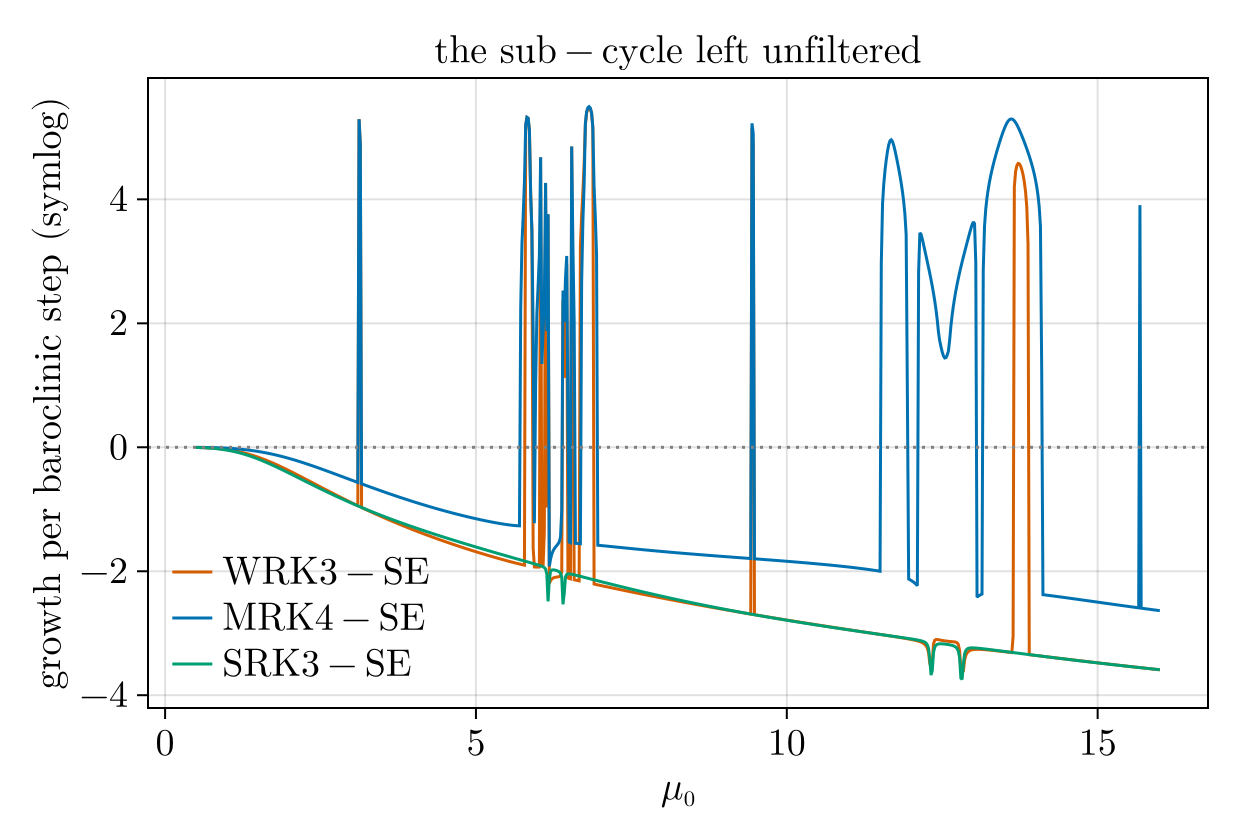

In [117]:
# ── Figure: the sub-cycle left unfiltered ────────────────────────────────────────────────────────
"The growth with no filter on the sub-cycle, where only the sign the coupling carries is left to decide it."
function figure_unfiltered(; ε = 0.06, Nm = 4, out = nothing)
    plot_setup(); set_theme!(theme_latexfonts(); fontsize = 19)
    slog(x; e = 1e-7) = sign(x)*log10(1 + abs(x)/e)
    μf = collect(0.5:0.02:16.0)                       # the unstable bands are narrow
    fig = Figure(size = (620, 420))
    ax = Axis(fig[1,1]; xlabel = L"\mu_0", ylabel = L"\text{growth per baroclinic step (symlog)}",
              title = L"\text{the sub-cycle left unfiltered}")
    for (nm, comp, ops, col) in ((L"\text{WRK3-SE}", WRK3, rk3_ops, "#D55E00"),
                                 (L"\text{MRK4-SE}", MRK4(0.23), rk3_ops, "#0072B2"),
                                 (L"\text{SRK3-SE}", SRK3, rk3_ops, "#009E73"))
        gr = [maximum(abs, eigvals(step_matrix(se_step, μ/(kx*c0()), ε, Nm, nofilter_weights(48);
                                               comp = comp, forcing = :frozen, ops = ops))) - 1 for μ in μf]
        lines!(ax, μf, slog.(gr); color = col, linewidth = 1.5, label = nm)
    end
    hlines!(ax, [0.0]; color = :gray, linestyle = :dot)
    axislegend(ax; position = :lb, framevisible = false)
    out === nothing || save(out, fig)
    fig
end

figure_unfiltered(out = "unfiltered.pdf")

#### Where the two eigenvalue families meet, and what the kernel reaches

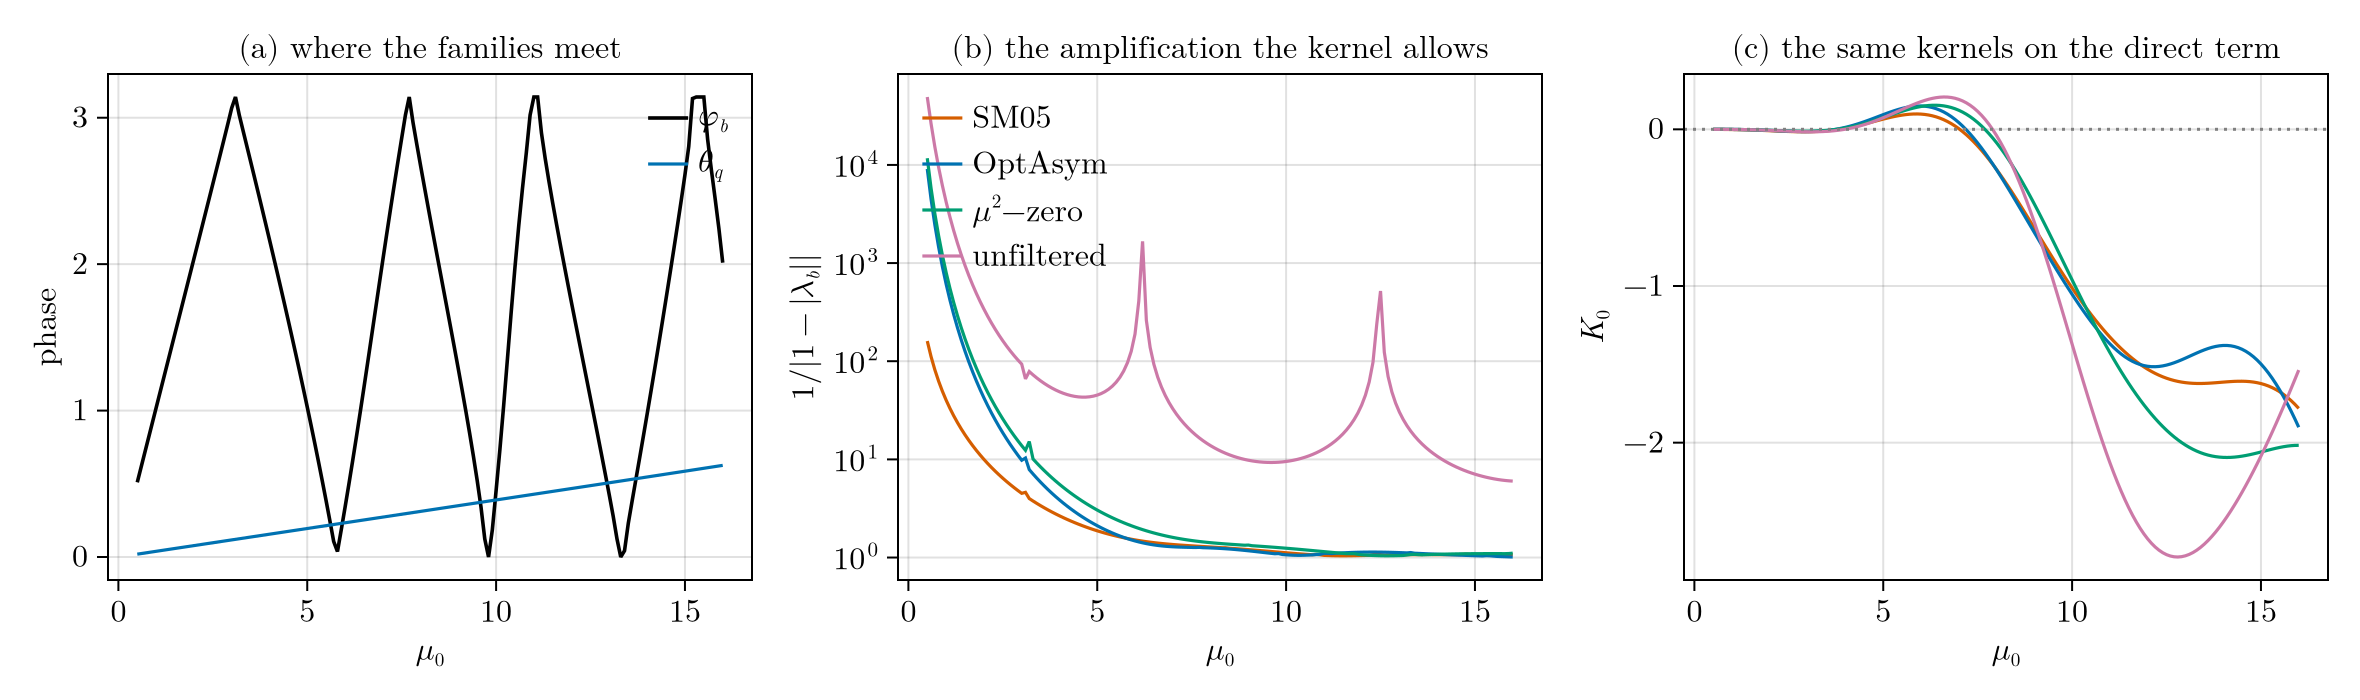

In [118]:
# ── Figure: what the averaging kernel controls, and what it does not ──────────────────────────────
"""
    figure_amplification(; ε, Nm, out)

The kernel sets how close the two eigenvalue families come, and that is the only quantity over which it
has leverage.  Panel (a) is the phase crossing; panel (b) the amplification `1/(1-|λ_b|)` each kernel
allows; panel (c) the same kernels' effect on the direct term, which is almost none.
"""
function figure_amplification(; ε = 0.06, Nm = 2, out = nothing)
    plot_setup()
    μs = collect(0.5:0.01:16.0)
    kers = ((L"\text{SM05}", sm05_weights(48), "#D55E00"), (L"\text{OptAsym}", optasym_weights(48), "#0072B2"),
            (L"\mu^2\text{-zero}", mu2zero_weights(48), "#009E73"), (L"\text{unfiltered}", nofilter_weights(48), "#CC79A7"))
    fig = Figure(size = (1180, 350))
    axa = Axis(fig[1,1]; xlabel = L"\mu_0", ylabel = L"\text{phase}",
               title = L"\text{(a) where the families meet}")
    axb = Axis(fig[1,2]; xlabel = L"\mu_0", yscale = log10, ylabel = L"1/|1-|\lambda_b||",
               title = L"\text{(b) the amplification the kernel allows}")
    axc = Axis(fig[1,3]; xlabel = L"\mu_0", ylabel = L"K_0",
               title = L"\text{(c) the same kernels on the direct term}")
    α, ψ = modes(ε, Nm); χq = ψ[2]*α[2]^2
    T0 = [shift_terms(μ, ε, Nm, optasym_weights(48); comp = WRK3, ops = rk3_ops) for μ in μs]
    lines!(axa, μs, [abs(angle(t.λb)) for t in T0]; color = :black, linewidth = 1.8, label = L"\varphi_b")
    lines!(axa, μs, [abs(angle(t.λ[t.j])) for t in T0]; color = "#0072B2", linewidth = 1.6, label = L"\theta_q")
    axislegend(axa; position = :rt, framevisible = false)
    for (lab, w, col) in kers
        T = [shift_terms(μ, ε, Nm, w; comp = WRK3, ops = rk3_ops) for μ in μs]
        lines!(axb, μs, [1/abs(1 - abs(t.λb)) for t in T]; color = col, linewidth = 1.6, label = lab)
        lines!(axc, μs, real.(getfield.(T, :n₀))./χq^2;  color = col, linewidth = 1.6, label = lab)
    end
    hlines!(axc, [0.0]; color = :gray, linestyle = :dot)
    axislegend(axb; position = :lt, framevisible = false)
    out === nothing || save(out, fig)
    fig
end

figure_amplification(out = "amplification.pdf")

#### What the forcing reconstruction removes, and what the four-stage composition needs

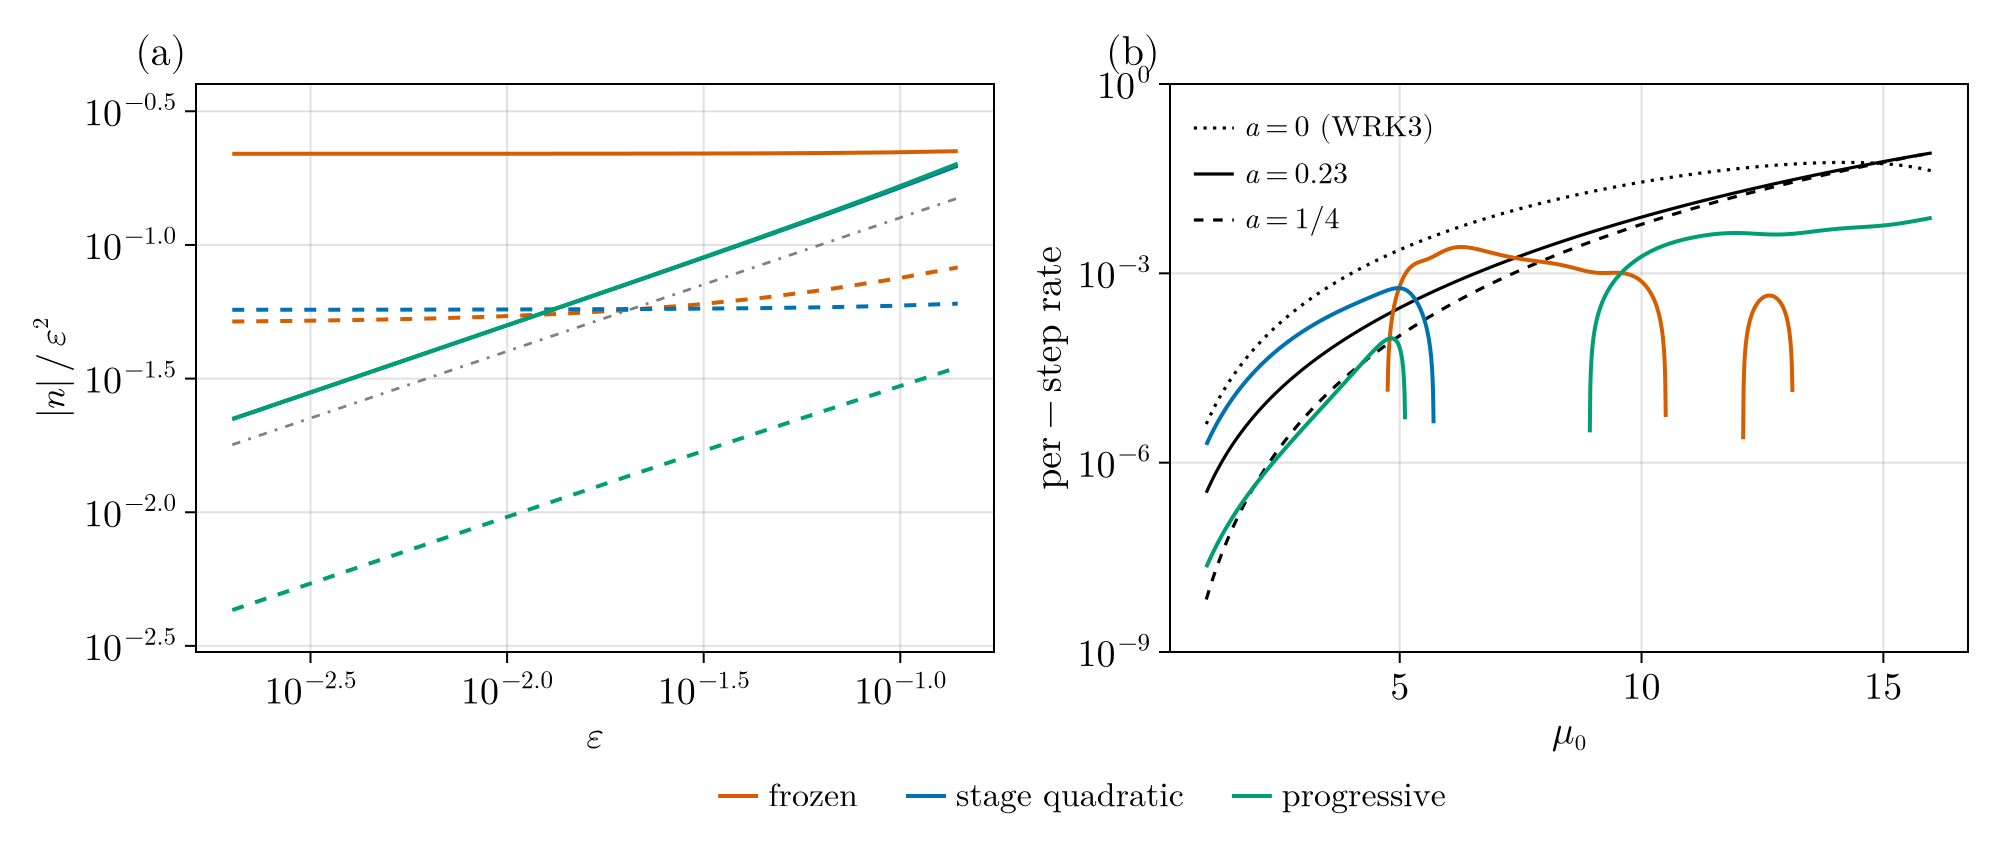

In [181]:
# ── Figure: what the forcing reconstruction removes, and what the four-stage composition can absorb
"""
    figure_reconstruction(; ε, Nm, μ₀, wts, out)

The slow forcing is held at one value inside a window while it turns by `θ_q = μ₀√ε` over the step, and that
misrepresentation is what generates the coupling numerator.  Panel (a) sweeps the stratification and shows which
numerator each treatment removes; panel (b) sets the injection that survives against the damping each quartic
coefficient can offer, the composition failing wherever a coloured curve rises above the black one for its `a`.
The injection is drawn only where positive; elsewhere it adds to the damping.
"""
function figure_reconstruction(; ε = 0.1, Nm = 8, μ₀ = 6.0, wts = optasym_weights(48), out = nothing)
    plot_setup(); set_theme!(theme_latexfonts(); fontsize = 19)
    treat = ((L"\text{frozen}", :frozen, "#D55E00"),
             (L"\text{stage quadratic}", :quadratic, "#0072B2"),
             (L"\text{progressive}", :progressive, "#009E73"))
    μs = collect(1.0:0.01:16.0)

    fig = Figure(size = (1000, 430))
    panel(r, c, s) = Label(fig[r, c, TopLeft()], s; fontsize = 20, padding = (0, 5, 5, 0), halign = :right)

    # (a) which numerator each treatment removes
    axa = Axis(fig[1,1];
               xscale = log10, yscale = log10,
               xlabel = L"\varepsilon",
               ylabel = L"|n| \,/\, \varepsilon^{2}")
    εs = 10 .^ range(log10(2e-3), log10(0.14), 12)
    for (_, f, col) in treat
        T = [shift_terms(μ₀, e, Nm, wts; comp = WRK3, ops = rk3_ops, forcing = f, qsel = 1) for e in εs]
        lines!(axa, εs, abs.(getfield.(T, :Kmeas))./εs.^2; color = col, linewidth = 2)
        lines!(axa, εs, abs.(getfield.(T, :n₀))./εs.^2;    color = col, linewidth = 2, linestyle = :dash)
    end
    lines!(axa, εs, 0.4 .* εs.^0.5; color = :gray, linewidth = 1.4, linestyle = :dashdot)
    ylims!(axa, 3e-3, 0.4)
    panel(1, 1, L"\text{(a)}")

    # (b) the injection against the damping each quartic coefficient can absorb
    axb = Axis(fig[1,2];
               yscale = log10,
               xlabel = L"\mu_0",
               ylabel = L"\text{per-step rate}")
    for (lab, comp, ls) in ((L"a = 0\ (\text{WRK3})", WRK3,       :dot),
                            (L"a = 0.23",             MRK4(0.23), :solid),
                            (L"a = 1/4",              MRK4(0.25), :dash))
        d = [-shift_terms(μ, ε, Nm, wts; comp = comp, ops = rk3_ops, qsel = 1).damping for μ in μs]
        lines!(axb, μs, d; color = :black, linewidth = 1.6, linestyle = ls, label = lab)
    end
    for (_, f, col) in treat
        s = [(t = shift_terms(μ, ε, Nm, wts; comp = MRK4(0.23), ops = rk3_ops,
                              forcing = f, qsel = 1);
              v = t.radial₀ + t.radial₂; v > 0 ? v : NaN) for μ in μs]
        lines!(axb, μs, s; color = col, linewidth = 2)
    end
    ylims!(axb, 1e-9, 1e0)
    axislegend(axb; position = :lt, framevisible = false, labelsize = 15)
    panel(1, 2, L"\text{(b)}")

    # one key, under both panels
    Legend(fig[2, 1:2],
           [LineElement(color = c, linewidth = 2) for (_, _, c) in treat],
           [l for (l, _, _) in treat];
           orientation = :horizontal, framevisible = false, labelsize = 17,
           colgap = 24, tellheight = true, tellwidth = false)
    rowgap!(fig.layout, 6)

    out === nothing || save(out, fig)
    fig
end

figure_reconstruction(out = "/Users/simonesilvestri/MIT Dropbox/Simone Silvestri/Apps/Overleaf/timestepper/reconstruction.pdf")

### 2.2b  What the kernel damps, and what the implicit solve damps instead


In [ ]:
# ── Figure: what the kernel damps per baroclinic step, against the implicit solve ─────────────────
"""
    figure_damping(; NS = 48, out = nothing)

Damping per baroclinic step against the barotropic Courant number `μ₀`.  For an averaging kernel the
gain is the transfer function of the weights sampled at the phase the sub-cycle advances over the step,
`Ŵ(μ₀) = Σ_s α^s exp(i μ₀ τ_s)`, so the damping is `1 - |Ŵ|`; the moment conditions make it
`M₂μ₀²/2` for a kernel that cancels nothing and `|M₄|μ₀⁴/24` for one with `M₂ = 0`.  The implicit free
surface has no kernel: its window contracts by `(1+μ₀²)^{-1/2}` whatever the sub-cycle.
"""
function figure_damping(; NS = 48, out = nothing)
    plot_setup()
    kernels = ((L"\text{SM05}",     sm05_weights(NS),     "#000000"),
               (L"M_2 = 0",         mu2zero_weights(NS),  "#D55E00"),
               (L"\text{trig}",     trig_weights(NS, 3/2, (-1.35, 0.5)),               "#009E73"),
               (L"\text{trig74}",   trig_weights(NS, 7/4, (-1.0, 0.5, -1.0, 0.5)),     "#56B4E9"),
               (L"\text{OptAsym}",  optasym_weights(NS),  "#0072B2"))

    function gain(wts, μ)
        Δτ, α = wts
        abs(sum(α[s]*cis(μ*s*Δτ) for s in eachindex(α)))
    end
    μs = 10 .^ range(-1, log10(8), length = 300)

    fig = Figure(size = (620, 430))
    ax = Axis(fig[1,1]; xscale = log10, yscale = log10,
              xlabel = L"\mu_0", ylabel = L"1 - |\hat{W}|",
              title = L"\text{damping per baroclinic step}")

    for (name, wts, col) in kernels
        d = [1 - gain(wts, μ) for μ in μs]
        m = findall(v -> isfinite(v) && v > 0, d)
        lines!(ax, μs[m], d[m]; color = col, label = name, linewidth = 2)
        @printf("%-10s  M₂ = %+.3e   M₄ = %+.3e\n", name, moment(wts..., 2), moment(wts..., 4))
    end

    # the implicit free surface: one solve per window, damping fixed by μ₀ alone
    lines!(ax, μs, 1 .- (1 .+ μs.^2).^(-1/2); color = "#CC79A7", linestyle = :dash, linewidth = 2,
           label = L"\text{implicit}")

    # reference slopes
    lines!(ax, μs, 2e-3 .* μs.^2; color = :gray, linestyle = :dot, label = L"\mu_0^2")
    lines!(ax, μs, 2e-4 .* μs.^4; color = :gray, linestyle = :dashdot, label = L"\mu_0^4")

    ylims!(ax, 1e-10, 1)
    axislegend(ax; position = :lt, framevisible = false, nbanks = 2)
    out === nothing || save(out, fig)
    fig
end


In [ ]:
figure_damping(out = "damping.pdf")

### 2.2 What the averaging kernel controls, and what the forcing controls

In [10]:
# ── Figures: what the kernel controls, what the forcing controls, and the proposed schemes ────────
symlog(x; ϵ = 1e-10) = sign(x)*log10(1 + abs(x)/ϵ)
function symticks(pw; ϵ = 1e-10)
    v = vcat([-10.0^p for p in reverse(pw)], 0.0, [10.0^p for p in pw])
    ([symlog(x; ϵ = ϵ) for x in v], vcat([L"-10^{%$p}" for p in reverse(pw)], L"0", [L"10^{%$p}" for p in pw]))
end
"The barotropic phase the scheme advances per baroclinic step, read in the decoupled limit."
baro_phase(μ, wts) = maximum(abs, angle.(eigvals(step_matrix(se_step, μ/(kx*c0()), 1e-8, 1, wts;
                                                             comp = WRK3, forcing = :frozen, ops = rk3_ops))))

function figure_collapse(; ε = 0.06, Nm = 2, out = nothing)
    plot_setup()
    KER = (("OptAsym", optasym_weights(48), "#0072B2"), ("M2zero", mu2zero_weights(48), "#009E73"),
           ("trig", trig_weights(48, 3//2, (-1.35, 0.5)), "#E69F00"), ("none", nofilter_weights(48), "#D55E00"))
    α, _ = modes(ε, Nm)
    fig = Figure(size = (1180, 380))
    μp = 4.6:0.02:7.4
    axa = Axis(fig[1,1]; xlabel = L"\mu_0", ylabel = L"\text{phase advanced per step}", title = L"\text{(a) the phases meet}")
    φb = [baro_phase(μ, optasym_weights(48)) for μ in μp]
    lines!(axa, μp, φb; color = :black, label = L"\varphi_b")
    lines!(axa, μp, μp*α[2]; color = "#D55E00", label = L"\theta_1 = \mu_0\alpha_1")
    lines!(axa, μp, μp*α[Nm+1]; color = "#0072B2", linestyle = :dash, label = L"\theta_{N_m}")
    roots = [μp[i] for i in 2:length(μp) if (φb[i-1]-μp[i-1]*α[2])*(φb[i]-μp[i]*α[2]) < 0]
    vlines!(axa, roots; color = (:black, 0.25), linestyle = :dot)
    axislegend(axa; position = :lt, framevisible = false, labelsize = 10)
    yt, yl = symticks(-8:2:-2)
    axb = Axis(fig[1,2]; xlabel = L"\mu_0", ylabel = L"\max_j|\lambda_j| - 1", yticks = (yt, yl),
               title = L"\text{(b) growth, kernel by kernel}")
    hlines!(axb, [0.0]; color = (:black, 0.35)); vlines!(axb, roots; color = (:black, 0.25), linestyle = :dot)
    μg = 3.0:0.02:9.0; peaks = NamedTuple[]
    for (nm, wk, col) in KER
        gs = [growth2(se_step, μ, ε, Nm, wk; comp = WRK3, forcing = :frozen, ops = rk3_ops) for μ in μg]
        lab = nm == "M2zero" ? L"M_2 = 0" : (nm == "OptAsym" ? L"\text{OptAsym}" : (nm == "trig" ? L"\text{trig}" : L"\text{none}"))
        lines!(axb, μg, symlog.(gs); color = col, label = lab)
        lc = [i for i in 2:length(μg)-1 if gs[i] > gs[i-1] && gs[i] > gs[i+1]]
        i = isempty(lc) ? argmax(gs) : lc[argmax(gs[lc])]
        Mb = step_matrix(se_step, μg[i]/(kx*c0()), ε, Nm, wk; comp = WRK3, forcing = :frozen, ops = rk3_ops)
        push!(peaks, (nm = nm, col = col, λb = min(maximum(abs, eigvals(blockdiag(Mb, Nm)[1:2,1:2])), 1 - 1e-4), g = gs[i]))
    end
    ylims!(axb, symlog(-6e-4), symlog(3e-4)); axislegend(axb; position = :lb, framevisible = false, labelsize = 9.5)
    axc = Axis(fig[1,3]; xlabel = L"1/(1 - |\lambda_b|)", ylabel = L"\text{growth at the maximum}", xscale = log10,
               yticks = (yt, yl), title = L"\text{(c) what the kernel controls}")
    for p in peaks
        scatter!(axc, [1/(1 - p.λb)], [symlog(p.g)]; color = p.col, markersize = 13)
        text!(axc, 1/(1 - p.λb), symlog(p.g); text = p.nm == "M2zero" ? "M₂ = 0" : p.nm, fontsize = 10,
              offset = p.nm == "OptAsym" ? (8,-14) : (p.nm == "M2zero" ? (8,4) : (p.nm == "trig" ? (8,10) : (-30,-16))), color = p.col)
    end
    xs = [1/(1-p.λb) for p in peaks]
    xlims!(axc, 10^(log10(minimum(xs))-0.45), 10^(log10(maximum(xs))+0.9))
    out === nothing || save(out, fig); fig
end

figure_collapse (generic function with 1 method)

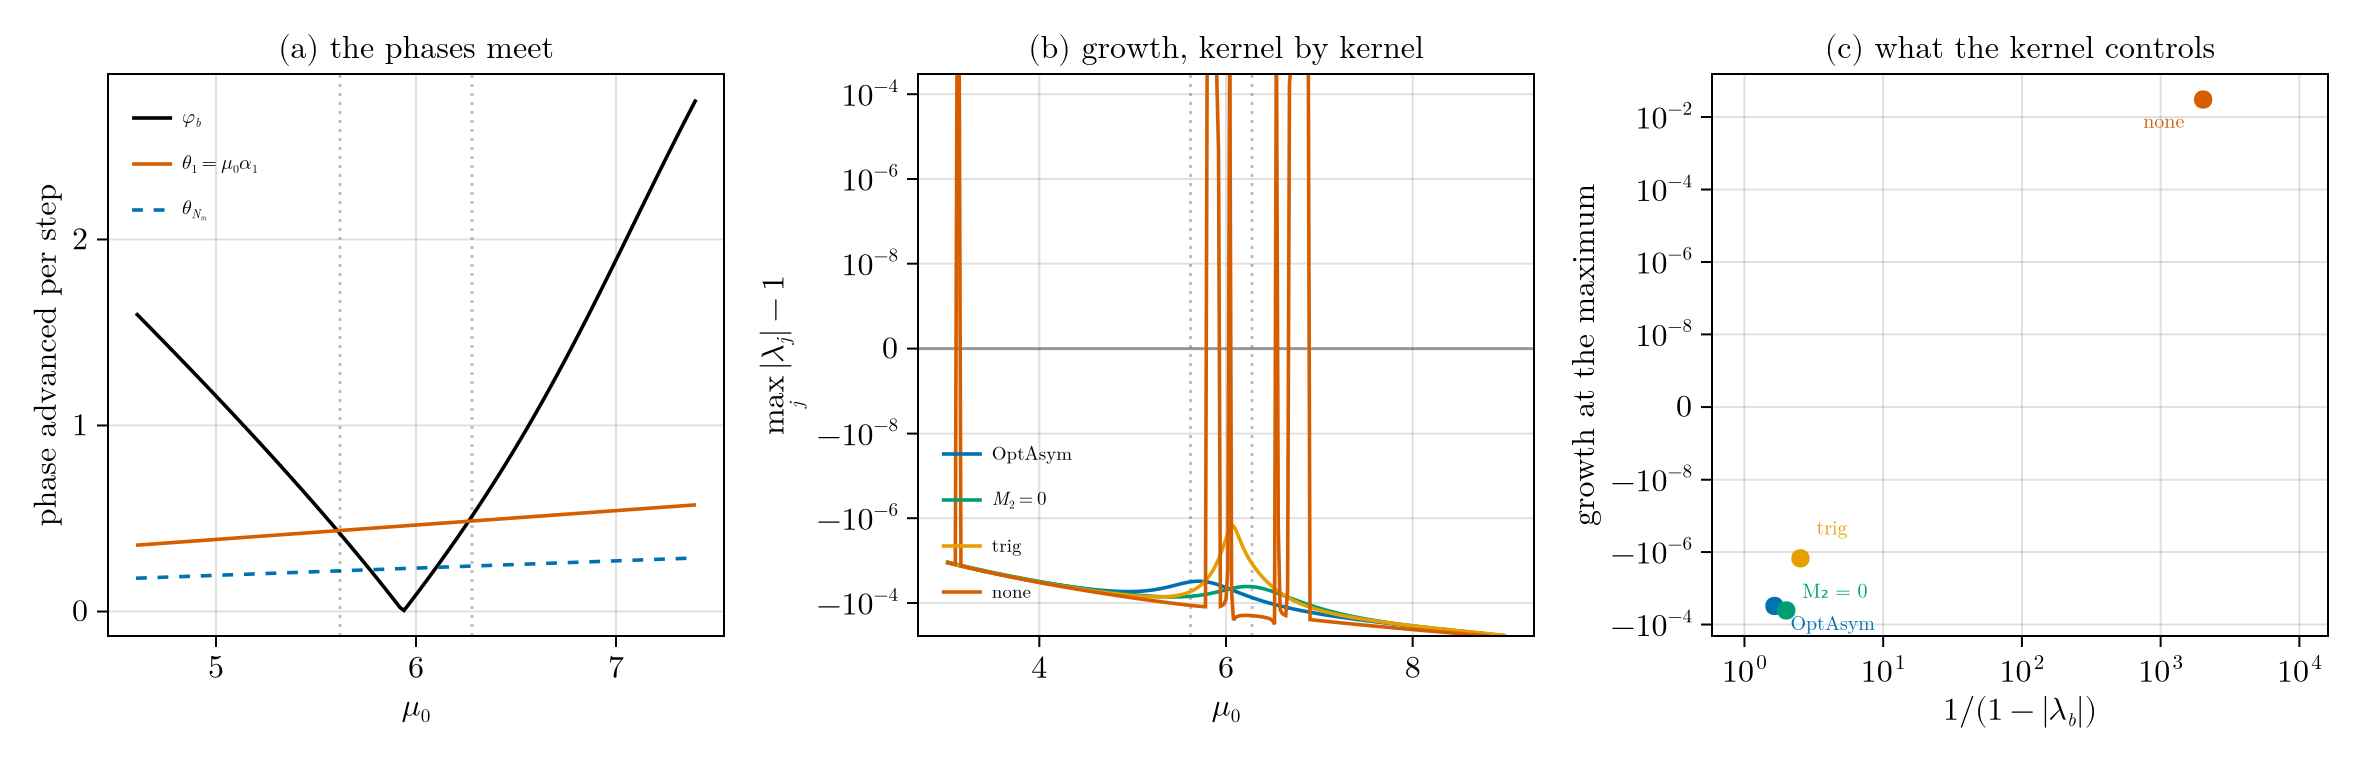

In [11]:
figure_collapse(out = "collapse.pdf")

In [12]:
function figure_forcing(; μ = 6.0, out = nothing)
    plot_setup()
    "the coupling numerator of the least damped baroclinic mode"
    function numerator(μ, ε; kw...)
        M = step_matrix(se_step, μ/(kx*c0()), ε, 1, optasym_weights(48); ops = exact_ops, kw...)
        Md = blockdiag(M, 1); V = M - Md
        F = eigen(Md); λ = F.values; R = F.vectors; L = inv(R); Ṽ = L*V*R
        mode(j) = argmax([abs(R[2q+1,j])^2 + abs(R[2q+2,j])^2 for q in 0:1]) - 1
        j = argmax([mode(i) > 0 ? abs(λ[i]) : -1.0 for i in 1:4])
        b = [l for l in 1:4 if mode(l) == 0]
        ks = [Ṽ[j,l]*Ṽ[l,j]/λ[j]^2 for l in b]
        abs(ks[argmax(abs.(ks))])
    end
    εs = 10.0 .^ (-2:-0.25:-6)   # below 1e-6 the baroclinic pair coalesces and the basis conditions poorly
    fro = [numerator(μ, ε; comp = WRK3, forcing = :frozen)    for ε in εs]
    qua = [numerator(μ, ε; comp = WRK3, forcing = :quadratic) for ε in εs]
    "a log axis cannot take a zero or a negative: drop those points rather than plot them"
    pos(x, y) = (m = findall(v -> isfinite(v) && v > 0, y); (collect(x)[m], y[m]))
    fig = Figure(size = (860, 370))
    ax1 = Axis(fig[1,1]; xscale = log10, yscale = log10, xlabel = L"\varepsilon", ylabel = L"|n|\ \text{rescaled}",
               title = L"\text{(a) the reconstruction cancels the leading term}")
    lines!(ax1, pos(εs, fro ./ εs.^2)...;   color = "#D55E00", label = L"\text{frozen}:\ |n|/\varepsilon^2")
    lines!(ax1, pos(εs, qua ./ εs.^2)...;   color = "#0072B2", label = L"\text{reconstructed}:\ |n|/\varepsilon^2")
    lines!(ax1, pos(εs, qua ./ εs.^2.5)...; color = "#0072B2", linestyle = :dash, label = L"\text{reconstructed}:\ |n|/\varepsilon^{5/2}")
    axislegend(ax1; position = :rb, framevisible = false)
    ax2 = Axis(fig[1,2]; xscale = log10, yscale = log10, xlabel = L"\varepsilon", ylabel = L"|n|/\varepsilon^2",
               title = L"\text{(b) no single value does}")
    for (s, col, lab) in ((0.0, "#999999", L"s = 0"), (0.5, "#D55E00", L"s = \Delta t/2\ \text{(frozen)}"), (1.0, "#333333", L"s = \Delta t"))
        v = [numerator(μ, ε; comp = WRK3, forcing = :frozen, sample = s) for ε in εs]
        lines!(ax2, pos(εs, v ./ εs.^2)...; color = col, label = lab)
    end
    lines!(ax2, pos(εs, qua ./ εs.^2)...; color = "#0072B2", label = L"\text{reconstructed}")
    axislegend(ax2; position = :rb, framevisible = false)
    out === nothing || save(out, fig); fig
end

figure_forcing (generic function with 1 method)

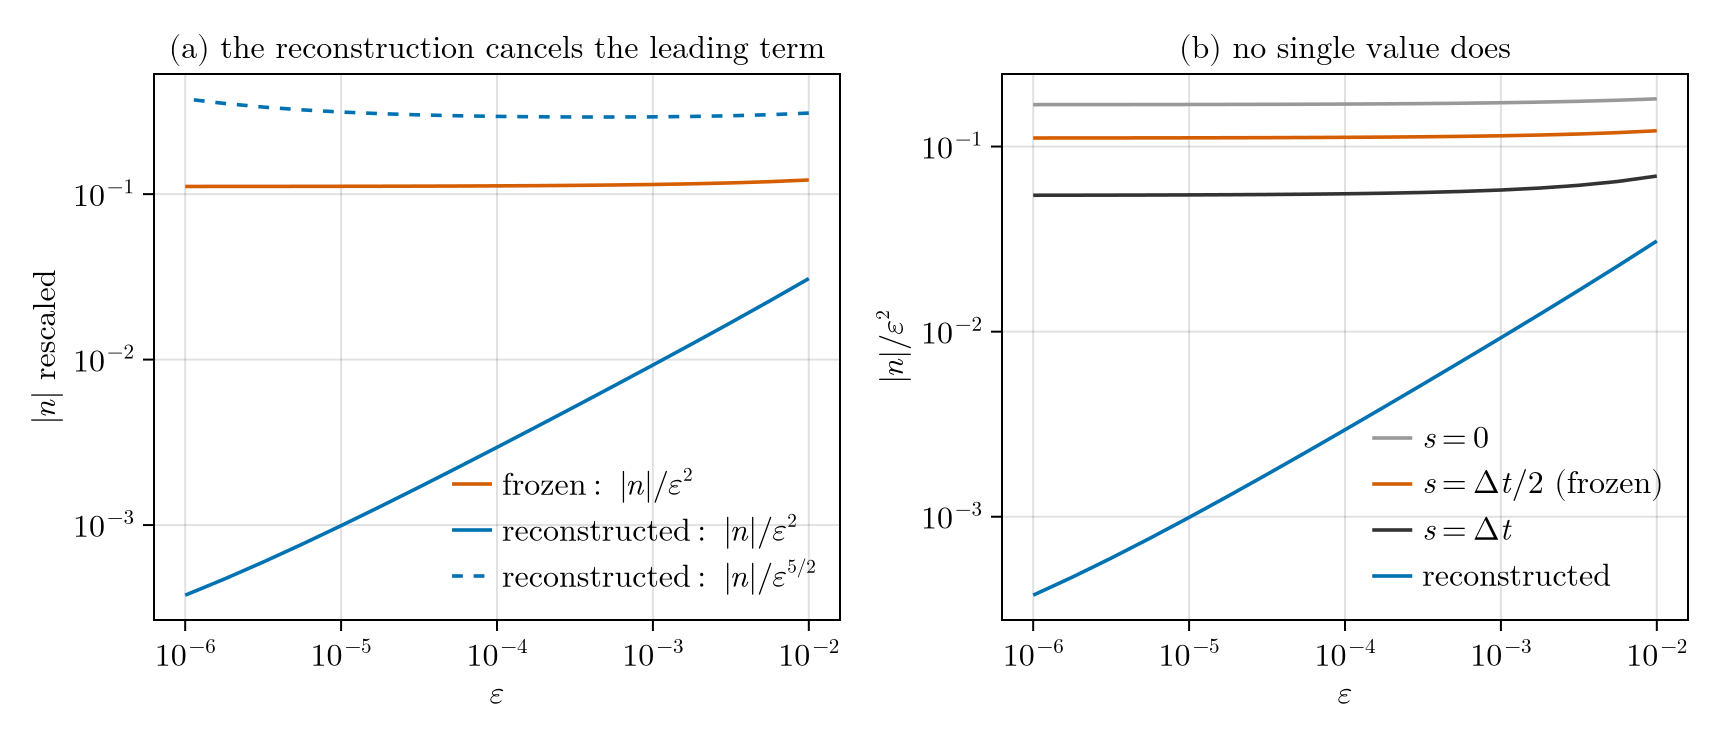

In [13]:
figure_forcing(out = "forcing.pdf")

### 2.3 The proposed schemes

Values are computed in double precision and recomputed in `BigFloat` wherever double precision is at
its floor, which is the small-$\mu_0$ end of the $N_m = 32$ panels.

In [14]:
# ── Figure: coupled stability of the proposed schemes ─────────────────────────────────────────────
# Double precision, recomputed in BigFloat wherever double precision is at its floor.
function figure_schemes(; out = nothing)
    plot_setup()
    setprecision(BigFloat, 128)
    W64 = Dict(:SM => sm05_weights(48), :OA => optasym_weights(48))
    WBF = Dict(:SM => sm05_weights(48, BigFloat), :OA => optasym_weights(48, BigFloat))
    "Growth in double precision, recomputed in BigFloat wherever double precision is at its floor."
    function g_hybrid(f, μ, ε, Nm)
        v = f(μ, ε, Nm, Float64, W64)
        abs(v) < 1e-12 ? Float64(f(μ, ε, Nm, BigFloat, WBF)) : v
    end
    SCHEMES = [
     (L"\text{AB2-SE}",       :black,    :dash,    (μ,ε,Nm,T,W) -> growth2(ab2_step, μ, ε, Nm, W[:SM]; T = T, ops = fb_ops)),
     (L"\text{WRK3-SE-SM05}", "#E69F00", :dash,    (μ,ε,Nm,T,W) -> growth2(se_step,  μ, ε, Nm, W[:SM]; T = T, comp = WRK3, forcing = :frozen, ops = fb_ops)),
     (L"\text{WRK3-SE}",      "#009E73", :solid,   (μ,ε,Nm,T,W) -> growth2(se_step,  μ, ε, Nm, W[:OA]; T = T, comp = WRK3, forcing = :quadratic, ops = rk3_ops)),
     (L"\text{SRK3-SE}",      "#CC79A7", :dash,    (μ,ε,Nm,T,W) -> growth2(se_step,  μ, ε, Nm, W[:OA]; T = T, comp = SRK3, forcing = :frozen, ops = rk3_ops)),
     (L"\text{MRK4-SE}",      "#0072B2", :solid,   (μ,ε,Nm,T,W) -> growth2(se_step,  μ, ε, Nm, W[:OA]; T = T, comp = MRK4(0.23), forcing = :progressive, ops = rk3_ops)),
     (L"\text{WRK3-IM}",      "#D55E00", :dashdot, (μ,ε,Nm,T,W) -> growth2(im_step,  μ, ε, Nm, W[:OA]; T = T)),
    ]
    μs = 0.5:0.5:44
    yt, yl = symticks(-8:3:-2)
    fig = Figure(size = (1120, 500))
    for (row, ε) in enumerate((0.05, 0.15)), (col, Nm) in enumerate((8, 32))
        α, _ = modes(ε, Nm)
        ax = Axis(fig[row, col]; yticks = (yt, yl),
                  xlabel = row == 2 ? L"\mu_0 = k c_0 \Delta t" : "",
                  ylabel = col == 1 ? L"\max_j|\lambda_j| - 1" : "",
                  title = L"\varepsilon = %$ε,\ N_m = %$Nm")
        hlines!(ax, [0.0]; color = (:black, 0.35), linewidth = 1)
        vlines!(ax, [√3/α[2]*0.29, √3/α[2], 2√2/α[2]]; color = (:black, 0.35), linestyle = :dot)
        for (lab, c, ls, f) in SCHEMES
            v = [g_hybrid(f, μ, ε, Nm) for μ in μs]
            lines!(ax, μs, symlog.(v); color = c, linestyle = ls, label = (row == 1 && col == 1) ? lab : nothing)
        end
        ylims!(ax, symlog(-3e-2), symlog(3e-4))
    end
    Legend(fig[1:2, 3], fig.content[1]; framevisible = false, labelsize = 11)

    out === nothing || save(out, fig)
    fig
end

figure_schemes (generic function with 1 method)

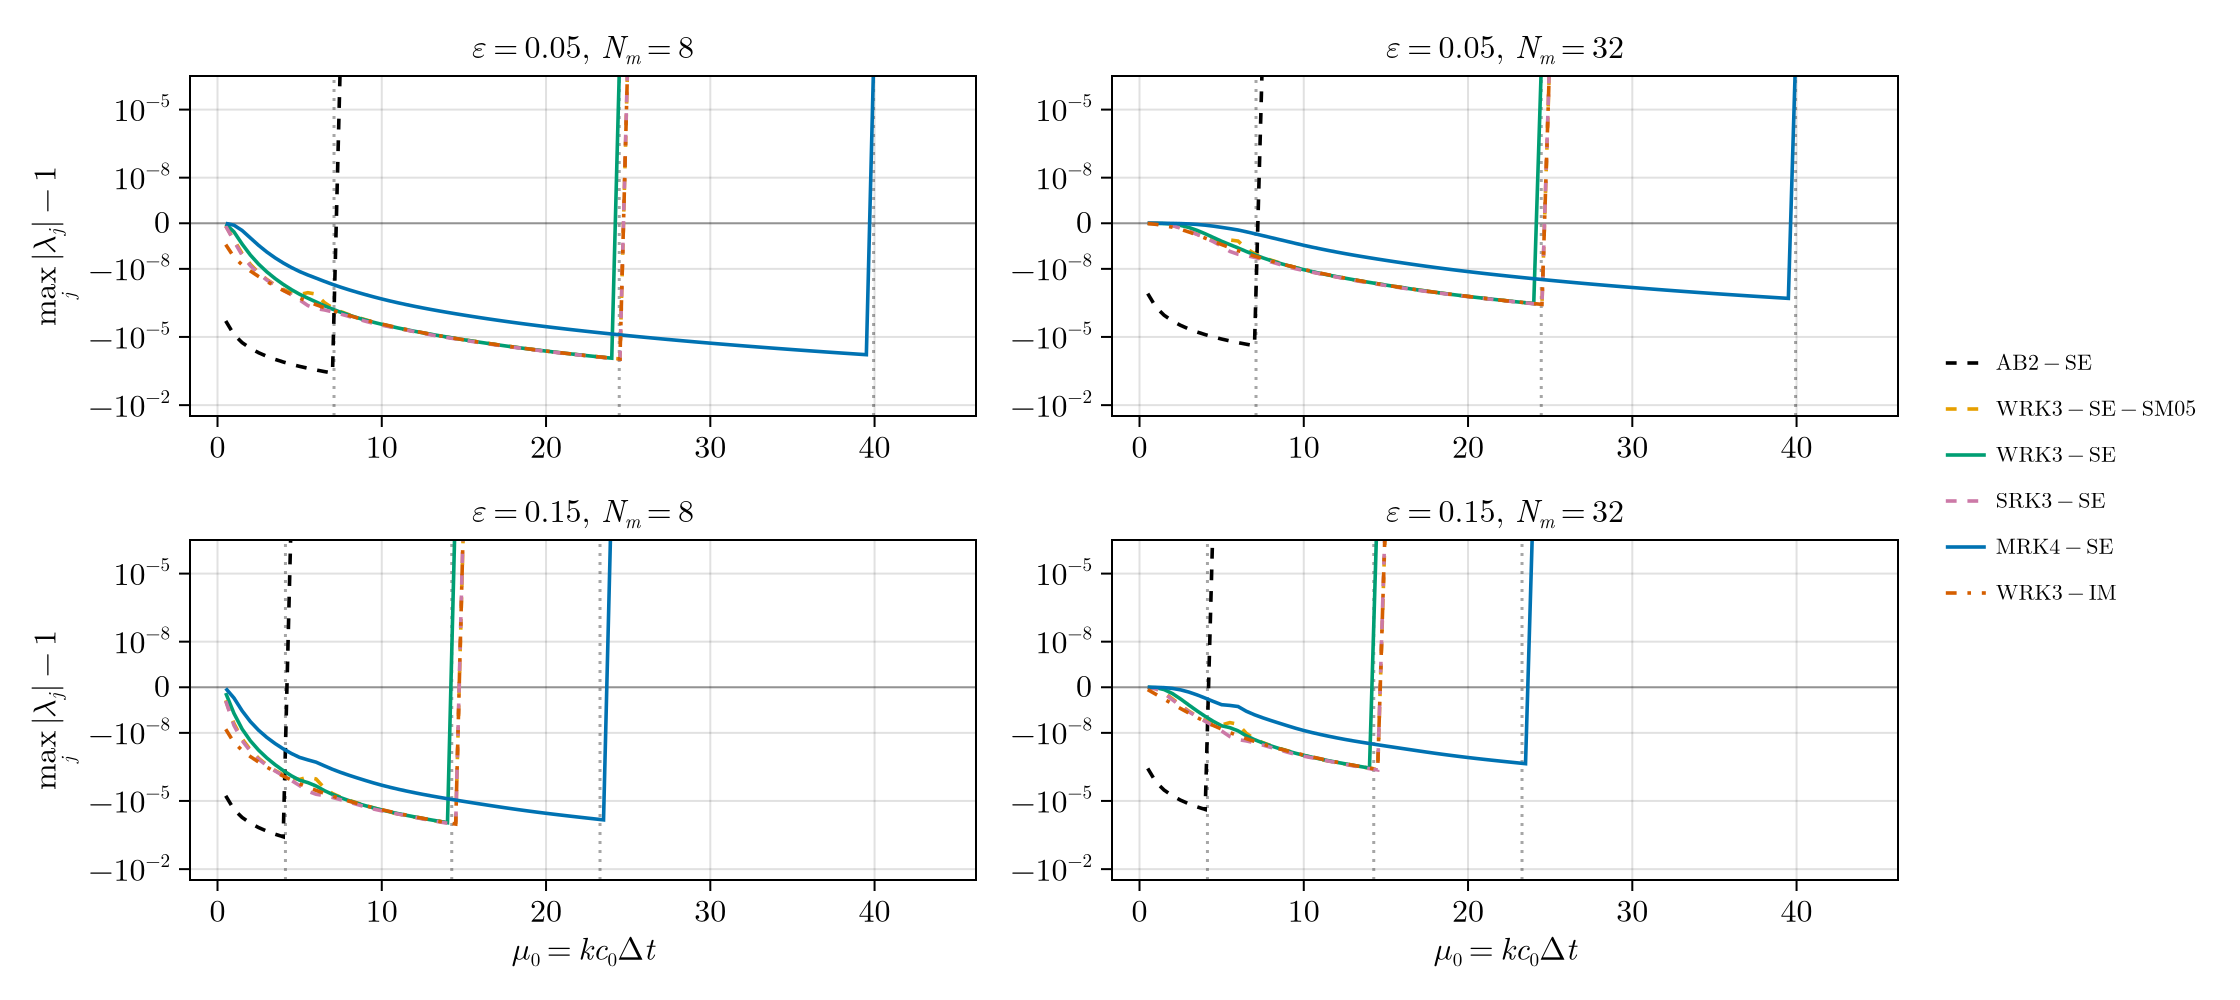

In [15]:
figure_schemes(out = "schemes.pdf")

### 2.4 Where the stable range ends

In [16]:
# ── Figures: where the stable range ends, and what sets it ────────────────────────────────────────
# The critical Courant number is the first μ₀ at which any eigenvalue leaves the unit disc.  It is
# swept against the truncation, against the stratification, and against the choice of kernel.
"First μ₀ on the grid at which the scheme grows; `nothing` becomes the top of the sweep."
function critical(f, μgrid)
    i = findfirst(μ -> f(μ) > 0, μgrid)
    i === nothing ? maximum(μgrid) : μgrid[i]
end
const KERNELS = (("trig",    trig_weights(48, 3//2, (-1.35, 0.5)),           "#E69F00"),
                 ("trig74",  trig_weights(48, 7//4, (-1.0, 0.5, -1.0, 0.5)), "#0072B2"),
                 ("M2zero",  mu2zero_weights(48),                            "#D55E00"),
                 ("OptAsym", optasym_weights(48),                            "#009E73"))
klabel(nm) = nm == "M2zero" ? L"M_2 = 0" :
             nm == "trig" ? L"\text{trig}" : (nm == "trig74" ? L"\text{trig74}" : L"\text{OptAsym}")

"Critical Courant number against the number of retained modes."
function figure_stab_modes(; ε = 0.10, Nms = (2, 4, 8, 16, 32), out = nothing)
    plot_setup()
    μgrid = 0.5:0.5:26
    α, _ = modes(ε, 2)
    fig = Figure(size = (660, 410))
    ax = Axis(fig[1,1]; xlabel = L"\text{number of baroclinic modes } N_m", ylabel = L"\text{critical } \mu_0",
              xscale = log2, xticks = collect(Nms))
    hlines!(ax, [√3/α[2]]; color = (:black, 0.4), linestyle = :dot)
    for (nm, wk, col) in KERNELS
        y = [critical(μ -> growth2(se_step, μ, ε, Nm, wk; comp = WRK3, forcing = :frozen, ops = rk3_ops), μgrid) for Nm in Nms]
        scatterlines!(ax, collect(Nms), y; color = col, marker = :circle, markersize = 8, label = klabel(nm))
    end
    # the narrow kernel once the injection is removed by the stage-value quadratic
    ytr = [critical(μ -> growth2(se_step, μ, ε, Nm, KERNELS[1][2]; comp = WRK3, forcing = :quadratic, ops = rk3_ops), μgrid) for Nm in Nms]
    scatterlines!(ax, collect(Nms), ytr; color = "#E69F00", linestyle = :dash, marker = :utriangle, markersize = 10,
                  label = L"\text{trig, stage-value quadratic}")
    axislegend(ax; position = :rc, framevisible = false, labelsize = 10)
    out === nothing || save(out, fig); fig
end

figure_stab_modes

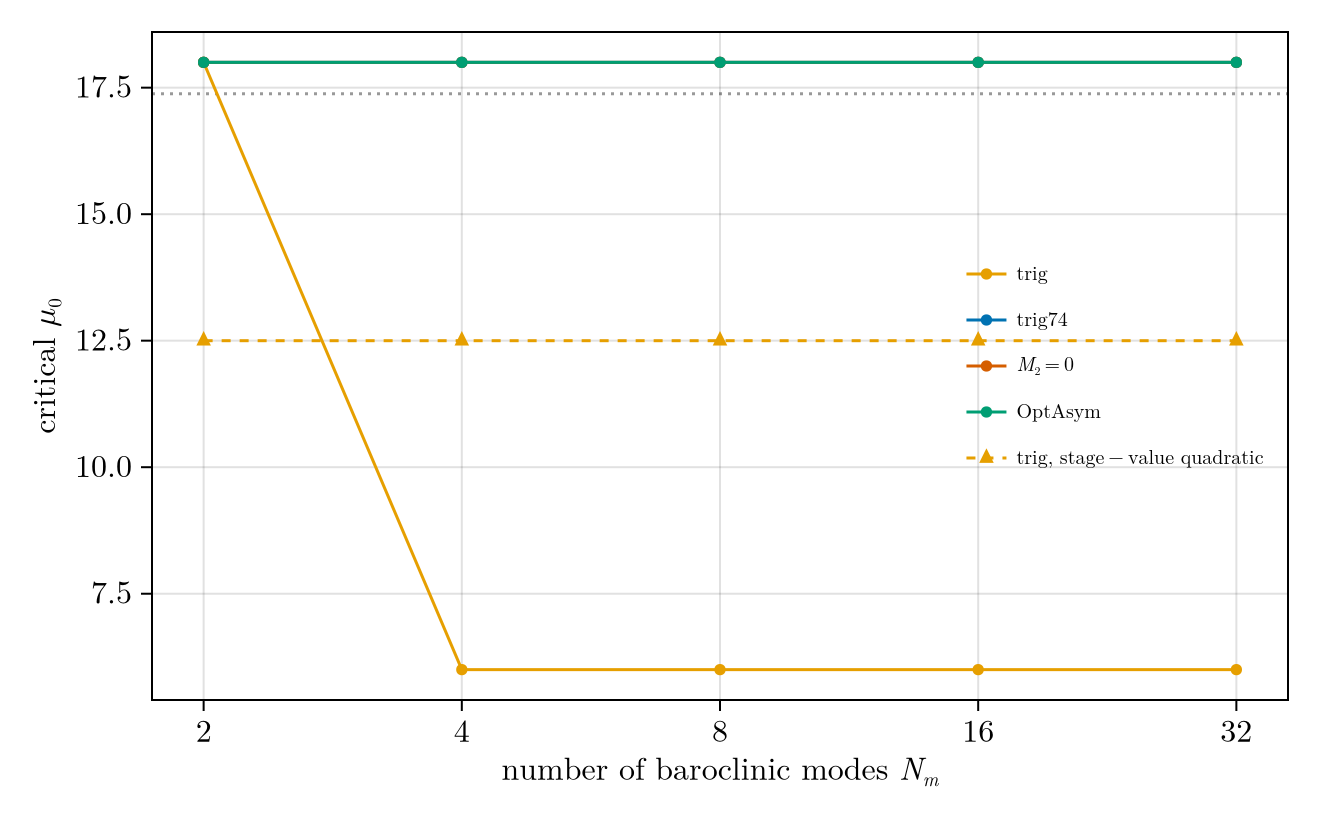

In [17]:
figure_stab_modes(out = "stab-modes.pdf")

In [18]:

"Critical Courant number against the stratification, for both sub-steps."
function figure_cliff(; Nm = 16, out = nothing)
    plot_setup()
    μgrid = 1.0:0.5:26
    εs = round.(10 .^ range(log10(0.02), log10(0.36), 17), sigdigits = 2)
    fig = Figure(size = (700, 430))
    ax = Axis(fig[1,1]; xlabel = L"\varepsilon = N^2 H / g", ylabel = L"\text{critical } \mu_0", xscale = log10)
    lines!(ax, εs, [(α = modes(ε, Nm)[1]; √3/α[2]) for ε in εs]; color = (:black, 0.4), linestyle = :dot,
           label = L"\sqrt{3}/\alpha_1")
    for (nm, wk, col) in KERNELS
        scatterlines!(ax, εs, [critical(μ -> growth2(se_step, μ, ε, Nm, wk; comp = WRK3, forcing = :frozen, ops = rk3_ops), μgrid) for ε in εs];
                      color = col, marker = :circle, markersize = 7, label = klabel(nm))
        lines!(ax, εs, [critical(μ -> growth2(se_step, μ, ε, Nm, wk; comp = WRK3, forcing = :frozen, ops = fb_ops), μgrid) for ε in εs];
               color = col, linestyle = :dash, linewidth = 1.2)
    end
    scatterlines!(ax, εs, [critical(μ -> growth2(se_step, μ, ε, Nm, KERNELS[1][2]; comp = WRK3, forcing = :quadratic, ops = rk3_ops), μgrid) for ε in εs];
                  color = "#E69F00", linestyle = :dash, marker = :utriangle, markersize = 9,
                  label = L"\text{trig, stage-value quadratic}")
    axislegend(ax; position = :rt, framevisible = false)
    out === nothing || save(out, fig); fig
end

figure_cliff

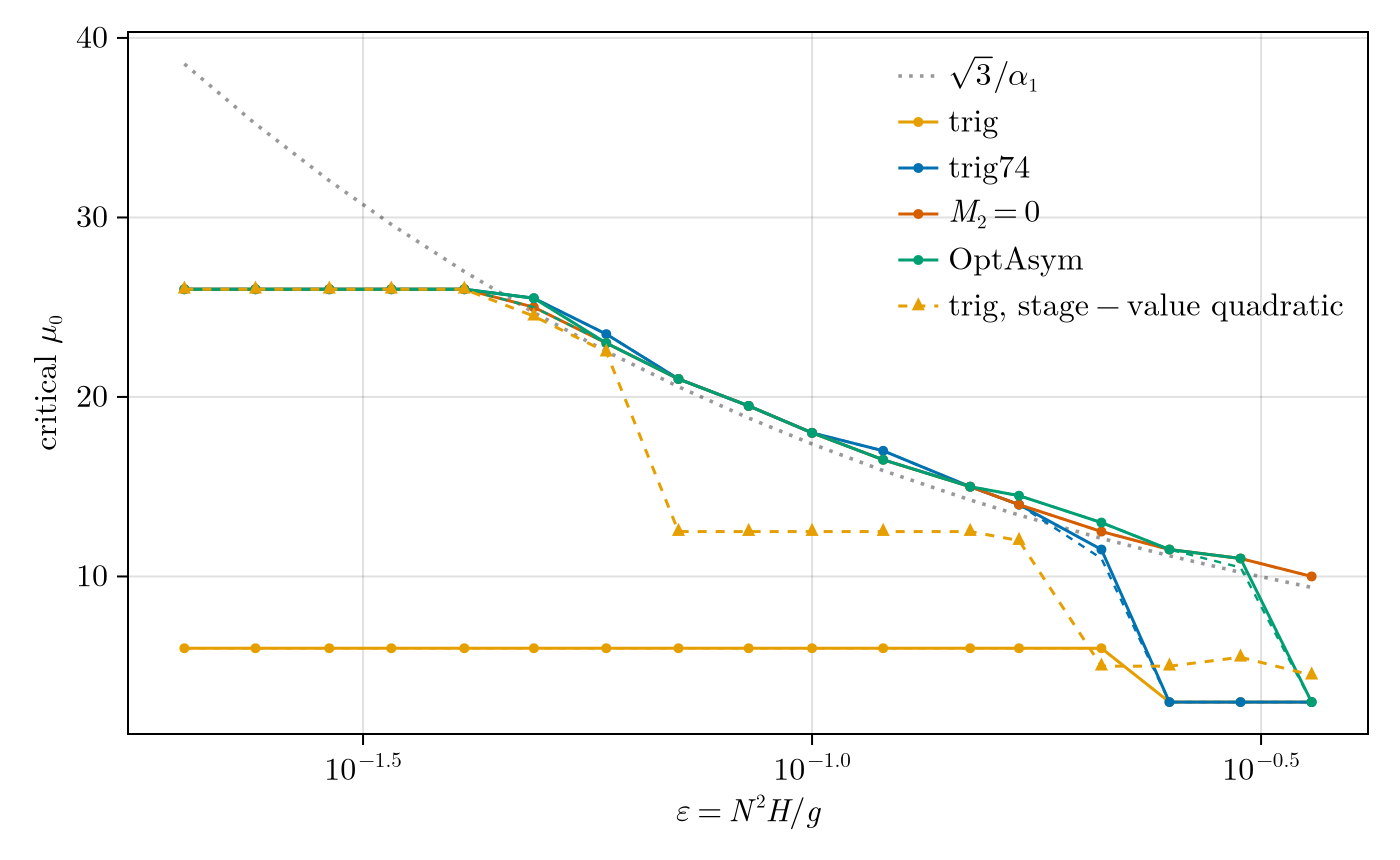

In [19]:
figure_cliff(out = "mu4-cliff.pdf")

### 2.5 The four-stage composition

In [20]:
# ── Figures: the four-stage composition ───────────────────────────────────────────────────────────
# The stability polynomial of the four-stage composition, and what it must absorb.
"Modulus of the composition's stability polynomial on the imaginary axis."
Rpoly(a, θ) = abs(1 + im*θ - θ^2/2 - im*θ^3/6 + (a/6)*θ^4)

"Coupled stability of the four-stage variants, full range and the weak band."
function figure_mrk4_stability(; ε = 0.06, Nm = 2, wts = optasym_weights(48), out = nothing)
    plot_setup()
    α, _ = modes(ε, Nm); r1 = α[2]
    g(; kw...) = μ -> growth2(se_step, μ, ε, Nm, wts; ops = rk3_ops, kw...)
    curves = [(L"\text{RK3, stage quadratic}",          "#009E73", :solid, g(comp = WRK3, forcing = :quadratic)),
              (L"\text{four-stage, frozen}",            "#E69F00", :solid, g(comp = MRK4(1/4), forcing = :frozen)),
              (L"\text{four-stage, final-stage quad.}", "#0072B2", :dash,  g(comp = MRK4(1/4), forcing = :quadratic)),
              (L"\text{four-stage, progressive}",       "#56B4E9", :solid, g(comp = MRK4(1/4), forcing = :progressive)),
              (L"\text{MRK4 } (a = 0.23)",              "#CC79A7", :solid, g(comp = MRK4(0.23), forcing = :progressive))]
    yt, yl = symticks(-8:2:0)
    fig = Figure(size = (1020, 390))
    axL = Axis(fig[1,1]; xlabel = L"\mu_0", ylabel = L"\max_j|\lambda_j| - 1", yticks = (yt, yl), title = L"\text{(a) full range}")
    axR = Axis(fig[1,2]; xlabel = L"\mu_0", yticks = (yt, yl), title = L"\text{(b) the weak baroclinic band}")
    for ax in (axL, axR); hlines!(ax, [0.0]; color = (:black, 0.35)); end
    vlines!(axL, [√3/r1, 2√2/r1]; color = (:black, 0.4), linestyle = :dot)
    for (lab, col, ls, f) in curves
        lines!(axL, 0.25:0.25:40, symlog.(f.(0.25:0.25:40)); color = col, linestyle = ls, label = lab)
        lines!(axR, 0.125:0.125:8, symlog.(f.(0.125:0.125:8)); color = col, linestyle = ls)
    end
    Legend(fig[1,3], axL; framevisible = false, labelsize = 10)
    out === nothing || save(out, fig); fig
end

figure_mrk4_stability

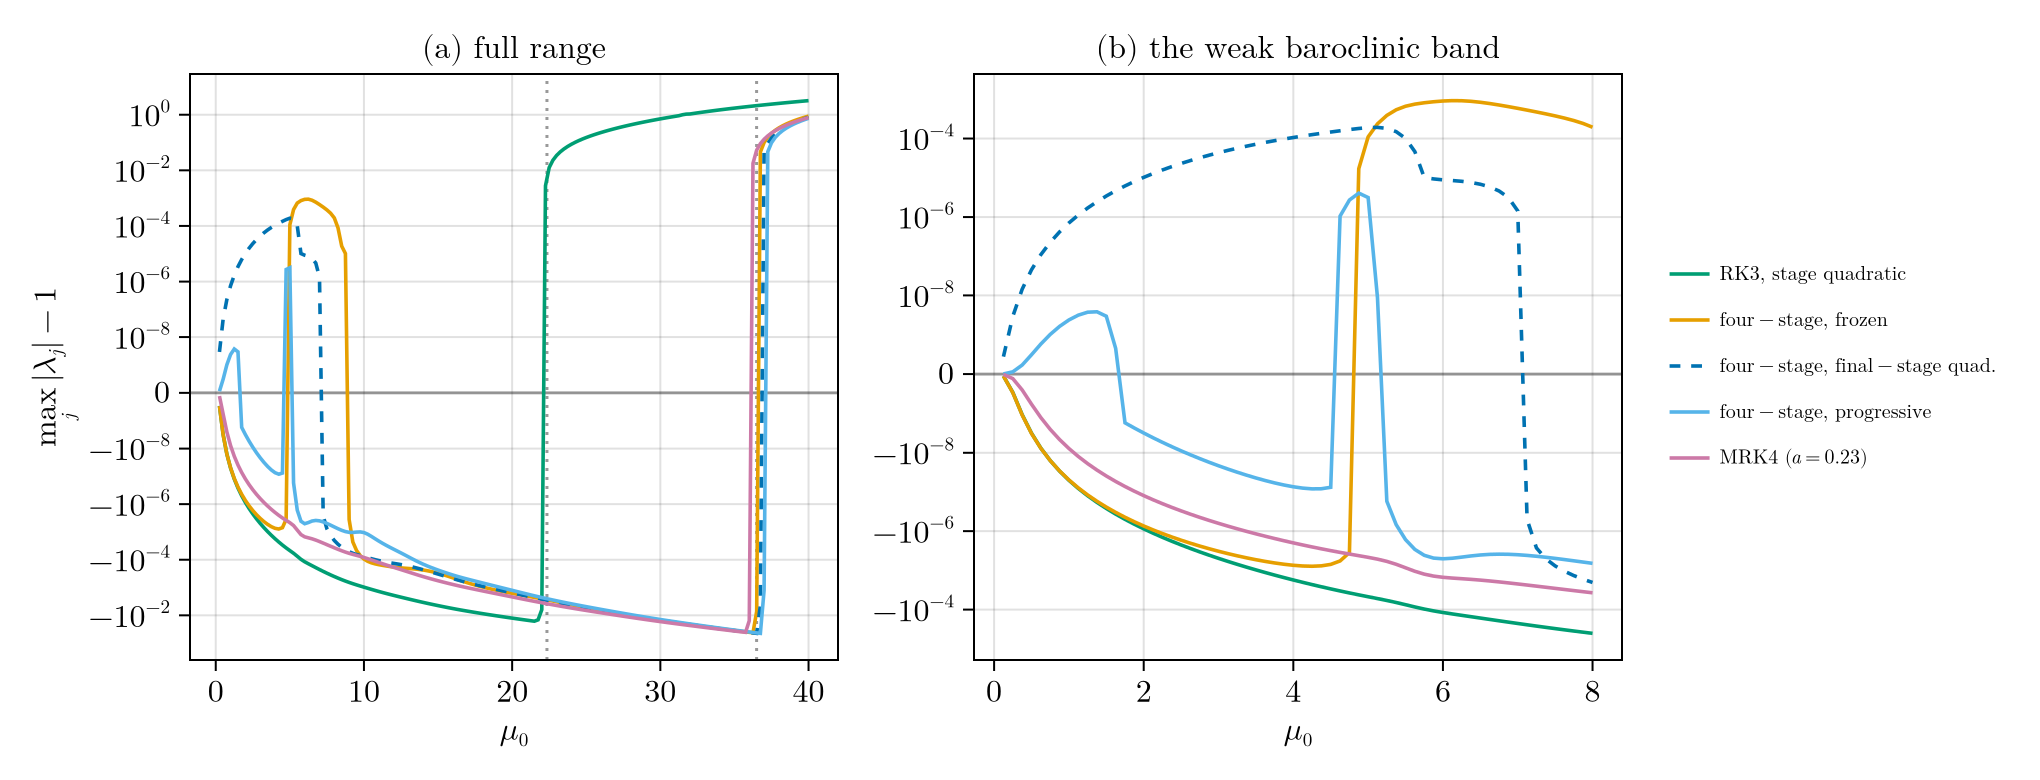

In [21]:
figure_mrk4_stability(out = "mrk4-stability.pdf")

In [22]:

"The mechanism of the weak band: the injection against the dissipation the polynomial can offer."
function figure_mrk4_mechanism(; ε = 0.1, Nm = 32, wts = optasym_weights(48), out = nothing)
    plot_setup()
    α, _ = modes(ε, Nm); r1 = α[2]
    μs = 10 .^ range(log10(0.5), log10(10), 60)
    # s(μ₀) is read off the a = 1/4 scheme, whose quartic dissipation vanishes: its growth IS the injection
    inj(f) = [growth2(se_step, μ, ε, Nm, wts; comp = MRK4(1/4), forcing = f, ops = rk3_ops) + 1 - Rpoly(1/4, μ*r1) for μ in μs]
    yt, yl = symticks(-10:2:-2; ϵ = 1e-11)
    fig = Figure(size = (720, 430))
    ax = Axis(fig[1,1]; xscale = log10, yscale = log10, xlabel = L"\mu_0", ylabel = L"\text{per-step rate}",
              title = L"\varepsilon = %$ε")
    hlines!(ax, [0.0]; color = (:black, 0.3))
    sl(v) = symlog.(v; ϵ = 1e-11)
    scatterlines!(ax, μs, [1 - Rpoly(1/4, μ*r1) for μ in μs]; color = :black, linestyle = :dash, markersize=5,
           label = L"\text{dissipation, } c_4 = 1/24\ (\propto\theta_1^6)")
    lines!(ax, μs, [1 - Rpoly(0.23, μ*r1) for μ in μs]; color = :black,
           label = L"\text{dissipation, } a = 0.23\ (\propto\theta_1^4)")
    lines!(ax, μs, [1 - Rpoly(0.0, μ*r1) for μ in μs]; color = (:black, 0.45), linestyle = :dashdot,
           label = L"\text{dissipation, } c_4 = 0\ \text{(WRK3, largest possible)}")
    lines!(ax, μs, inj(:frozen);      color = "#E69F00", label = L"s(\mu_0)\text{, frozen}")
    lines!(ax, μs, inj(:quadratic);   color = "#0072B2", linestyle = :dash, label = L"s(\mu_0)\text{, final-stage quadratic}")
    lines!(ax, μs, inj(:progressive); color = "#CC79A7", label = L"s(\mu_0)\text{, progressive}")
    Legend(fig[1,2], ax; framevisible = false)
    out === nothing || save(out, fig); fig
end

figure_mrk4_mechanism

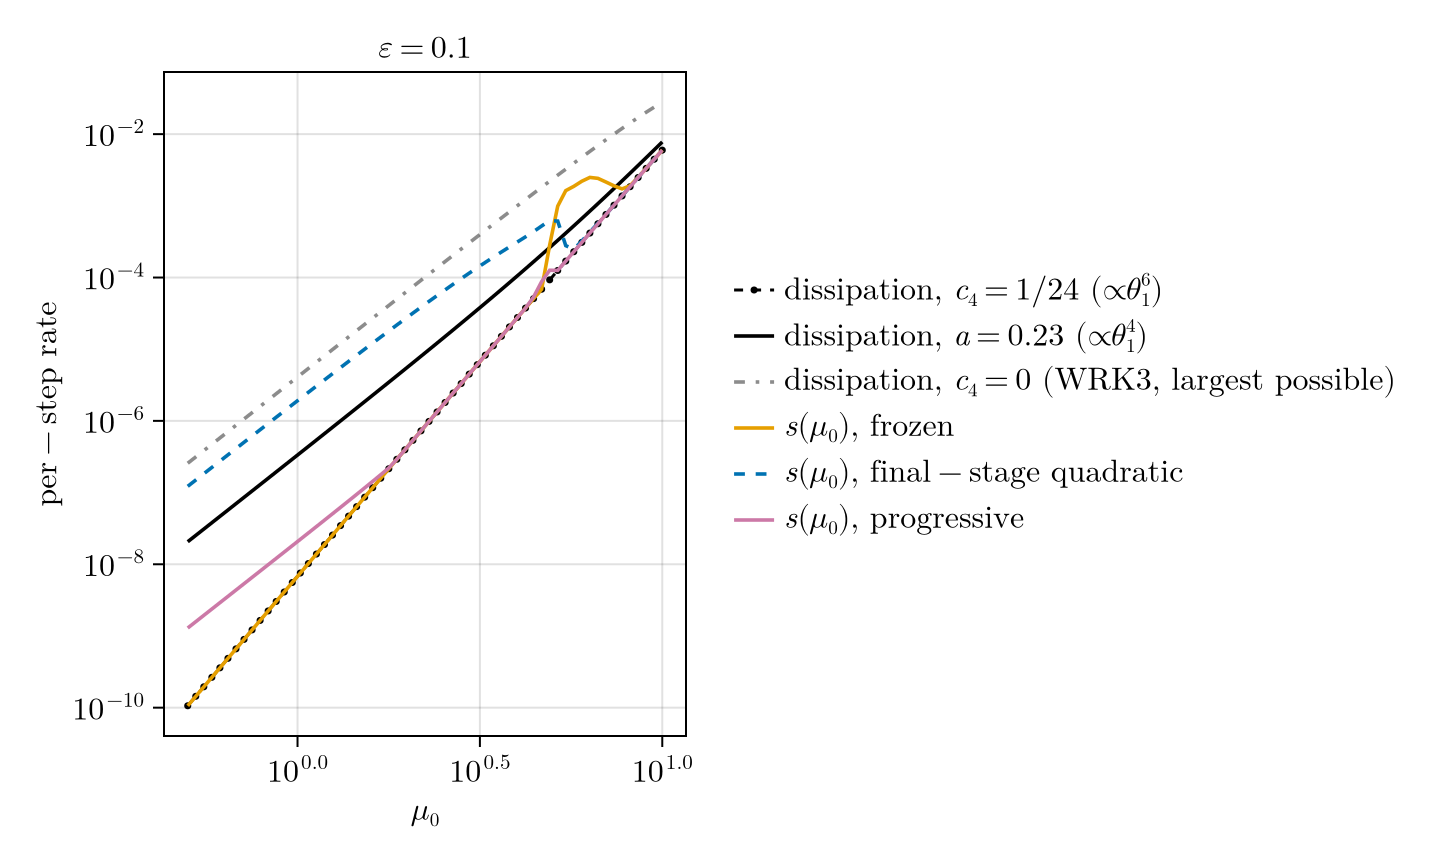

In [23]:
figure_mrk4_mechanism(out = "mrk4-mechanism.pdf")

### 2.6 Accuracy

The order of the barotropic sub-cycle alone, and the order of the coupled step.

For the sub-cycle the window error is governed by the first central moment of the averaging
kernel that does not vanish: a kernel with $M_2 = \dots = M_{p-1} = 0$ and $M_p \neq 0$ leaves an
error $\mathcal{O}(\mu_0^p)$. The hierarchy is only realised if the sub-step is itself accurate
enough to expose it, which is why the two sub-steps are drawn apart.

The coupled order is read at the small-$\Delta t$ end: the ceiling is asymptotic, and above that
range a higher-order term still dominates the error.

The one-step error of the four-stage compositions is reported as a table rather than a figure:
three of the four curves agree to within $4\times10^{-4}$ and would draw a single line.


In [24]:
# ── Accuracy: the order of the sub-cycle, and the order of the coupled step ───────────────────────
# The reference is the exact modal propagator; errors are measured in the energy norm, which
# symmetrises each mode by (u_q, g h_q / c_q) so that velocities and thicknesses are comparable.
exact_propagator(Δt, ε, Nm) = exp(modal_generator(ε, Nm)*Δt)
"""
The norm in which the exact modal evolution is unitary: mode q symmetrised by (u_q, g h_q/c_q), so
that a velocity error and a thickness error are commensurate and each mode is weighted by its own
energy.  In the raw variables the norm mixes m/s with m and is dominated by whichever component
carries the larger scale factor.  ŷ = S y, so an operator becomes S M S⁻¹.
"""
function energy_scaling(ε, Nm)
    α, _ = modes(ε, Nm)
    Diagonal(ComplexF64[isodd(j) ? 1/c0() : 1/(H*α[(j+1)÷2]) for j in 1:2(Nm+1)])
end
"Error of one step against the exact propagator, in the energy norm."
function onestep_error(stepper, μ, ε, Nm, wts; kw...)
    Δt = μ/(kx*c0())
    S  = energy_scaling(ε, Nm)
    opnorm(S*(step_matrix(stepper, Δt, ε, Nm, wts; kw...) - exact_propagator(Δt, ε, Nm))*inv(S))
end
"Error after integrating to a fixed horizon, so that halving Δt doubles the number of steps."
function global_error(stepper, μ, ε, Nm, wts; horizon = 64.0, kw...)
    Δt = μ/(kx*c0()); n = round(Int, horizon/(kx*c0()*Δt))
    S  = energy_scaling(ε, Nm)
    M  = step_matrix(stepper, Δt, ε, Nm, wts; kw...)
    opnorm(S*(M^n - exact_propagator(n*Δt, ε, Nm))*inv(S))
end
"""
Order read at the small-Δt end: the ceiling is an asymptotic statement, and above the asymptotic
range a higher-order term still dominates, so a slope measured at large μ₀ would overstate it.
"""
function asymptotic_slope(μs, e; window = 4)
    log(e[window]/e[1])/log(μs[window]/μs[1])
end

"""
Order of the barotropic sub-cycle alone, against the exact barotropic advance over one window.

The window error of a filtered sub-cycle is governed by the first central moment of the averaging
kernel that does not vanish: a kernel with M₂ = … = M_{p-1} = 0 and M_p ≠ 0 leaves an error O(μ₀^p).
That hierarchy is only visible if the sub-step itself is accurate enough to expose it, which is why
the two sub-steps are drawn apart: with the RK3 sub-step the kernels separate by their moments,
while with the forward–backward sub-step the sub-step's own second-order error covers all of them
and the kernel design buys nothing.
"""
function figure_order_barotropic(; out = nothing)
    plot_setup()
    μs = 10 .^ range(-2.4, 0.3, 22)
    KER = (("OptAsym", optasym_weights(48), "#009E73", 4), ("trig74", trig_weights(48, 7//4, (-1.0,0.5,-1.0,0.5)), "#0072B2", 4),
           ("M2zero", mu2zero_weights(48), "#D55E00", 3), ("SM05", sm05_weights(48), "#E69F00", 2))
    function err(wts, ops)          # `vals`, not `out`: a nested function would capture the keyword
        vals = Float64[]
        for μ in μs
            Δt = μ/(kx*c0())
            a, _, _ = stage_ops(Δt, wts, g, ops)                  # the filtered sub-cycle
            e, _, _ = stage_ops(Δt, (1//1, [1.0]), g, exact_ops)  # the exact barotropic advance
            push!(vals, opnorm(a - e))
        end
        vals
    end
    """
    A slope indicator: a short dotted segment running parallel to the curve it explains, offset below
    it, spanning one decade at the small-Δt end.  A short segment stays beside its own curve instead
    of cutting across the others, which a full-width guide cannot avoid when the slopes differ.
    """
    function guide!(ax, e, p, lab; drop = 10.0, at = 1, span = 7)
        μa, μb = μs[at], μs[at+span]
        ya = e[at]/drop
        lines!(ax, [μa, μb], [ya, ya*(μb/μa)^p]; color = (:black, 0.45), linestyle = :dot)
        # labelled below the segment: every curve that can cross a short guide crosses it from above
        text!(ax, μb, ya*(μb/μa)^p; text = lab, color = (:black, 0.6), fontsize = 11,
              align = (:left, :top), offset = (3, -1))
    end
    fig = Figure(size = (900, 400))
    yt = 10.0 .^ (-13:2:-1)                 # whole decades: half-decade ticks are unreadable on a log axis
    panels = (("(a) RK3 sub-step", rk3_ops), ("(b) forward–backward sub-step", fb_ops))
    for (j, (title, ops)) in enumerate(panels)
        ax = Axis(fig[1, j]; xscale = log10, yscale = log10, xlabel = L"\mu_0 = k c_0 \Delta t",
                  ylabel = j == 1 ? L"\Vert \mathcal{A}(\Delta t) - e^{\mathcal{L}_b \Delta t} \Vert" : "",
                  yticks = (yt, [L"10^{%$(Int(round(log10(y))))}" for y in yt]),
                  title = L"\text{%$title}")
        drawn = Int[]                       # one indicator per distinct slope, not one per kernel
        for (nm, wk, col, _) in KER
            e = err(wk, ops)
            s = log(e[4]/e[1])/log(μs[4]/μs[1])
            p = round(Int, s)
            lines!(ax, μs, e; color = col, label = L"\text{%$nm},\ \ \text{slope } %$(round(s, digits = 1))")
            p in drawn || (push!(drawn, p); guide!(ax, e, p, L"\mu_0^{%$p}"))
        end
        ylims!(ax, 1e-14, 3e-1)
        j == 2 && hideydecorations!(ax; grid = false, ticks = false, minorticks = false)
        axislegend(ax; position = :lt, framevisible = false, labelsize = 9)
    end
    out === nothing || save(out, fig); fig
end

"The order ceiling of the coupled step: global error over a fixed horizon."
function figure_order_ceiling(; ε = 0.06, Nm = 2, wts = optasym_weights(48), out = nothing)
    plot_setup()
    μs = 10 .^ range(log10(1e-3), log10(0.5), 16)
    cases = ((L"\text{WRK3, frozen}",            "#E69F00", (comp = WRK3,       forcing = :frozen)),
             (L"\text{WRK3, stage quadratic}",   "#009E73", (comp = WRK3,       forcing = :quadratic)),
             (L"\text{SRK3}",                    "#CC79A7", (comp = SRK3,       forcing = :frozen)),
             (L"\text{MRK4, progressive}",       "#0072B2", (comp = MRK4(0.23), forcing = :progressive)))
    fig = Figure(size = (680, 430))
    yt = 10.0 .^ (-11:2:-1)
    ax = Axis(fig[1,1]; xscale = log10, yscale = log10, xlabel = L"\mu_0 = k c_0 \Delta t",
              ylabel = L"\text{error at a fixed horizon } T = 64/(k c_0)",
              yticks = (yt, [L"10^{%$(Int(round(log10(y))))}" for y in yt]))
    es = Vector{Float64}[]
    for (lab, col, kw) in cases
        e = [global_error(se_step, μ, ε, Nm, wts; ops = rk3_ops, kw...) for μ in μs]
        s = round(asymptotic_slope(μs, e), digits = 2)
        lines!(ax, μs, e; color = col, label = L"%$lab,\ \text{order } %$s")
        push!(es, e)
    end
    # Short, labelled slope keys placed under the curves.  A full-width guide of slope 2 lies on top of
    # the curves it is meant to compare against, and one of slope 3 has to cross them; short segments
    # offset below the lowest curve do neither.
    lo = [minimum(e[i] for e in es) for i in eachindex(μs)]
    for (i0, span, p, div) in ((1, 6, 2, 5.0), (7, 6, 3, 60.0))
        μa, μb = μs[i0], μs[i0+span]; y0 = lo[i0]/div
        lines!(ax, [μa, μb], [y0, y0*(μb/μa)^p]; color = (:black, 0.45), linestyle = :dot)
        text!(ax, μb, y0*(μb/μa)^p; text = L"\mu_0^{%$p}", color = (:black, 0.6), fontsize = 11,
              align = (:left, :top), offset = (3, -1))
    end
    axislegend(ax; position = :rb, framevisible = false)
    out === nothing || save(out, fig); fig
end

"""
One-step error of the four-stage compositions against the three-stage reference, reported as a table
rather than a figure: on a log-log plot three of the four curves fall within 0.4% of each other and
draw a single line, so the numbers carry what the picture cannot.

The point is the constant, not the slope. All four are third order locally, hence second order
globally, which is the ceiling of `figure_order_ceiling`. What the forcing reconstruction changes is
how far above the reference the composition sits; what the damping modification `a` changes is
nothing at all.
"""
function report_mrk4_error(; ε = 0.06, Nm = 2, wts = optasym_weights(48))
    μs = (0.4, 0.2, 0.1, 0.05, 0.025, 0.0125)
    err(kw) = [onestep_error(se_step, μ, ε, Nm, wts; ops = rk3_ops, kw...) for μ in μs]
    quad = err((comp = WRK3,       forcing = :quadratic))     # the three-stage reference
    froz = err((comp = MRK4(1//4), forcing = :frozen))
    prog = err((comp = MRK4(1//4), forcing = :progressive))
    damp = err((comp = MRK4(0.23), forcing = :progressive))
    slope(e) = log(e[end]/e[end-2])/log(μs[end]/μs[end-2])
    @printf("one-step error in the energy norm, ε = %.2f, Nm = %d\n\n", ε, Nm)
    @printf("   μ₀      RK3 quadratic   frozen/quadratic   |prog - quad|/quad   |a=0.23 - a=1/4|/(a=1/4)\n")
    for i in eachindex(μs)
        @printf("  %6.4f     %.3e         %5.2f             %8.1e              %8.1e\n",
                μs[i], quad[i], froz[i]/quad[i], abs(prog[i] - quad[i])/quad[i], abs(damp[i] - prog[i])/prog[i])
    end
    @printf("\nlocal slopes: %.2f, %.2f, %.2f, %.2f  (third order locally = second order globally)\n",
            slope(quad), slope(froz), slope(prog), slope(damp))
    return (; quad, froz, prog, damp)
end


report_mrk4_error

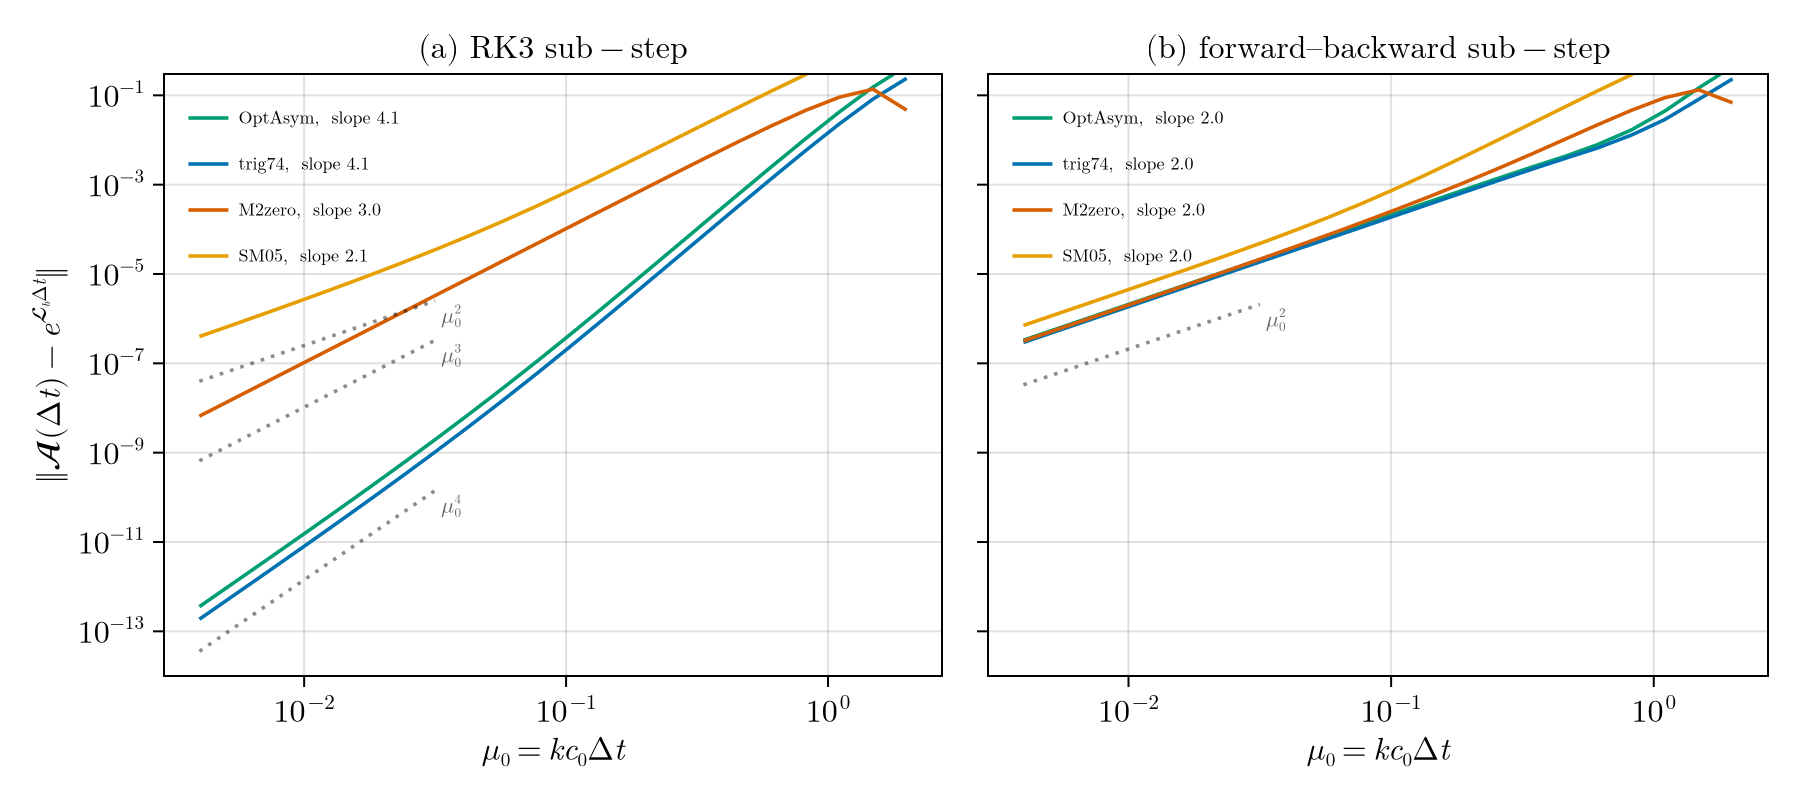

In [25]:
figure_order_barotropic(out = "order-barotropic.pdf")

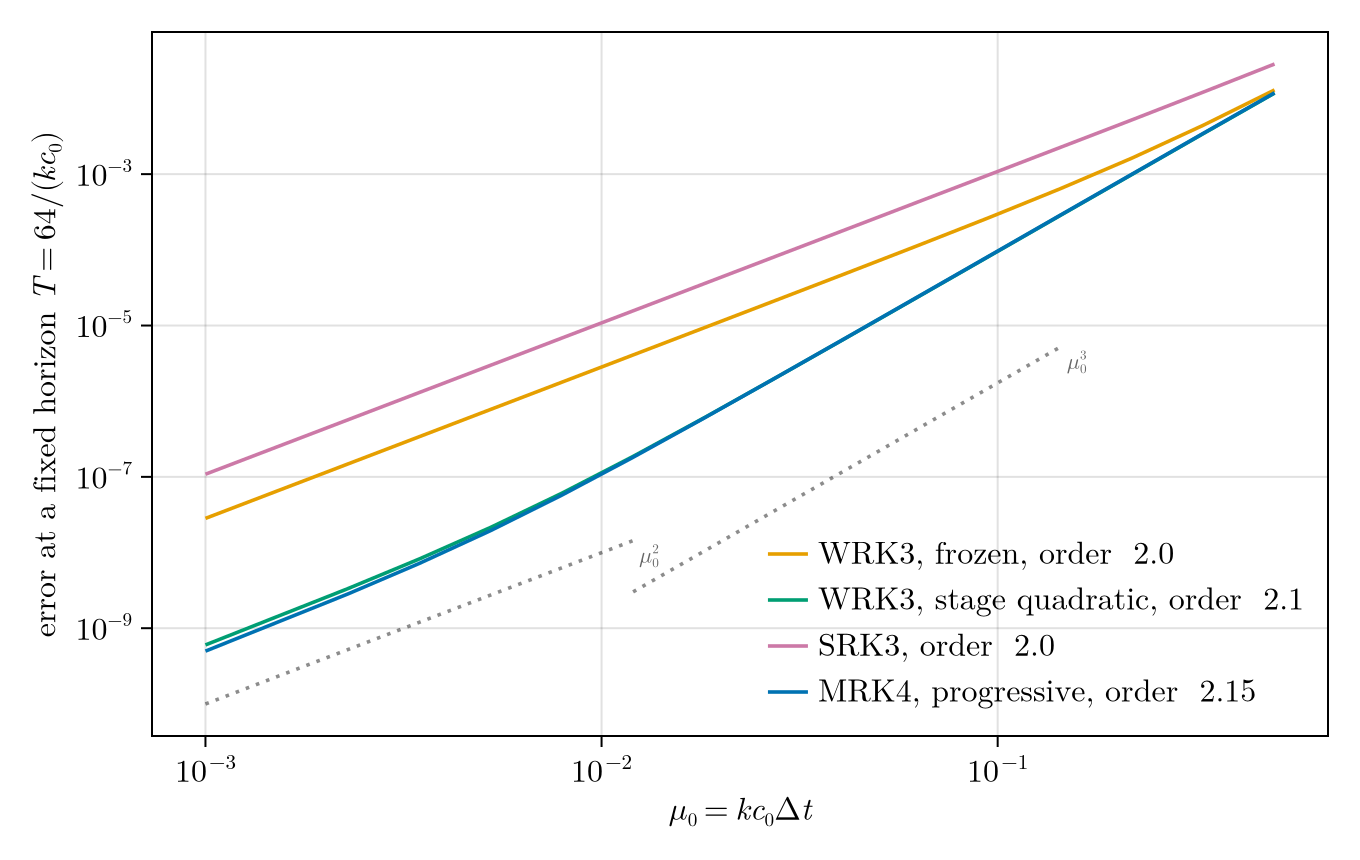

In [26]:
figure_order_ceiling(out = "order-ceiling.pdf")

In [27]:
report_mrk4_error()


one-step error in the energy norm, ε = 0.06, Nm = 2

   μ₀      RK3 quadratic   frozen/quadratic   |prog - quad|/quad   |a=0.23 - a=1/4|/(a=1/4)
  0.4000     4.341e-05          3.03              3.5e-03               6.5e-05
  0.2000     3.748e-06          4.06              1.4e-03               2.7e-05
  0.1000     3.990e-07          4.65              7.2e-04               1.2e-05
  0.0500     4.746e-08          4.86              4.9e-04               8.1e-06
  0.0250     5.854e-09          4.92              4.3e-04               7.2e-06
  0.0125     7.293e-10          4.93              4.1e-04               6.9e-06

local slopes: 3.01, 3.00, 3.01, 3.01  (third order locally = second order globally)


(quad = [4.340522966981708e-5, 3.7481226507176757e-6, 3.99044999728853e-7, 4.7458949376356474e-8, 5.85422221108375e-9, 7.293150245507945e-10], froz = [0.00013152385425665075, 1.5228442255112276e-5, 1.857491090915935e-6, 2.3065192439775779e-7, 2.8782696055462317e-8, 3.596305328315026e-9], prog = [4.325449026513378e-5, 3.742713119855533e-6, 3.9875603034807115e-7, 4.7435604501115195e-8, 5.85171121255921e-9, 7.290139393603765e-10], damp = [4.325169789882125e-5, 3.742612527331087e-6, 3.9875131212729475e-7, 4.743522054701831e-8, 5.851669276606208e-9, 7.290088839220044e-10])